# Figures of the main text and the appendix

*A generative framework for precise topology engineering of polymer networks* (npj Computational Materials).

Regenerates the data figures of the manuscript from `data/`. No simulation is run. Every input path is relative to this
folder, and a missing input raises `FileNotFoundError` (there are no fallbacks to mock data).

Run from this folder:
`python -m nbconvert --to notebook --execute generate_figures.ipynb --output generate_figures_executed.ipynb`

| Cell | Manuscript | Data |
|---|---|---|
| Figure 1 (`Figure_1_RDF`) | Fig. 2 | `data/dataset.pkl` |
| Figure 2 (`Figure_2_Scaling_and_Distributions`) | Fig. 3 | `data/dataset.pkl` |
| Figure 3 (`Figure_3_Characteristic_Ratio`) | Fig. 4 | `data/dataset.pkl`, Brownian-bridge model with seed 20260924 |
| Figure 4 (`Figure_4_Tg`) | Fig. 5 | `data/derived/tg/tg_msd_histories.csv` (three cooling histories) |
| Figure 5 (`Figure_5_Mechanical_State`) | Fig. 6 | `data/dataset.pkl` graphs and `data/derived/mechanics/mechanics_pulls_4seeds.csv` (12 pulls per network) |
| Figure 6 (`Figure_6_Contrast_Maps`) | Fig. 7 | the same |
| Pearson (`pearson_correlation_matrix.png`) | not in the manuscript | the same |
| Appendix (`Figure_A2_entanglement`) | Fig. 8 (Appendix B) | `data/derived/entanglement/` |
| Appendix (`Figure_A1_bondcreate`) | Fig. 9 (Appendix C) | `data/derived/bond_create/` |

Figures 1-3 use the data and code of v0.1.0 (Figure 3 now has a fixed random seed). Figures 4-6, the Pearson matrix and
the appendix figures use the derived data in `data/derived/`. Every change to the v0.1.0 cells is marked
`# CHANGE (v0.2.0)`.

In [1]:
# --- Setup & Config ---
import warnings
# CHANGE (v0.2.0): silence two harmless warnings whose text carries local file paths (scipy 1.15.2 with numpy 2.5.2,
# see requirements.txt; matplotlib's note that a constrained-layout figure skips tight_layout)
warnings.filterwarnings('ignore', message='A NumPy version', category=UserWarning)
warnings.filterwarnings('ignore', message='This figure was using a layout engine', category=UserWarning)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import os
import sys
from scipy.stats import norm, ttest_ind, skew, kurtosis
from scipy.optimize import curve_fit

sys.path.append(os.path.abspath('data'))
from npj_style_v1 import set_npj_style, add_panel_label

output_dir = 'figs'
os.makedirs(output_dir, exist_ok=True)
print(f'GLOBAL output_dir set to: {output_dir}')

SAVE_DPI = 600

DATA_PATH = 'data'
REV_PATH = os.path.join(DATA_PATH, 'derived')   # CHANGE (v0.2.0): derived data (see data/derived/README.md)


def require(path):
    """CHANGE (v0.2.0): fail loudly. Every input path is relative to this notebook's folder."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required input not found: {path}. Run the notebook from its own folder (see README.md).")
    return path


def read_csv_exact(path, **kwargs):
    """CHANGE (v0.2.0): parse floats exactly (pandas' default parser can be off in the last bit)."""
    return pd.read_csv(require(path), float_precision='round_trip', **kwargs)


def load_mechanics_12pull():
    """CHANGE (v0.2.0): the deposited network table (dataset.pkl) with the mechanical columns replaced by
    means over 12 pulls per network (3 axes x 4 velocity seeds, data/derived/mechanics/mechanics_pulls_4seeds.csv).
    The published figures used 3 pulls (3 axes x 1 seed); *_std are population SDs (ddof=0) as before."""
    with open(require(os.path.join(DATA_PATH, 'dataset.pkl')), 'rb') as f:
        df = pickle.load(f)['mechanics'].copy()
    pulls = read_csv_exact(os.path.join(REV_PATH, 'mechanics', 'mechanics_pulls_4seeds.csv'))
    nets = list(df.index)
    if len(pulls) != 12 * len(nets) or set(pulls['folder_name']) != set(nets):
        raise ValueError('mechanics_pulls_4seeds.csv must hold 3 axes x 4 seeds for every network in dataset.pkl')
    pulls = pulls.assign(_i=pulls['folder_name'].map({n: i for i, n in enumerate(nets)})).sort_values(['_i', 'axis', 'seed'])
    grid = pulls[['axis', 'seed']].to_numpy().reshape(len(nets), 12, 2)
    if not (grid == pulls[['axis', 'seed']].to_numpy()[:12]).all():
        raise ValueError('mechanics_pulls_4seeds.csv: every network needs axes x, y, z and seeds 1-4')
    cube = {p: pulls[p].to_numpy().reshape(len(nets), 3, 4) for p in ('uts', 'toughness', 'sab')}   # network x axis x seed
    n = len(nets)
    df['uts_mean'] = cube['uts'].mean((1, 2))
    df['toughness_mean'] = cube['toughness'].mean((1, 2))
    df['strain_break_mean'] = cube['sab'].mean((1, 2))
    df['uts_std'] = cube['uts'].reshape(n, -1).std(1, ddof=0)
    df['toughness_std'] = cube['toughness'].reshape(n, -1).std(1, ddof=0)
    df['strain_break_std'] = cube['sab'].reshape(n, -1).std(1, ddof=0)
    df['num_directions'] = 12
    return df


GLOBAL output_dir set to: figs


Figure 1 re-generated with dynamic label alignment.


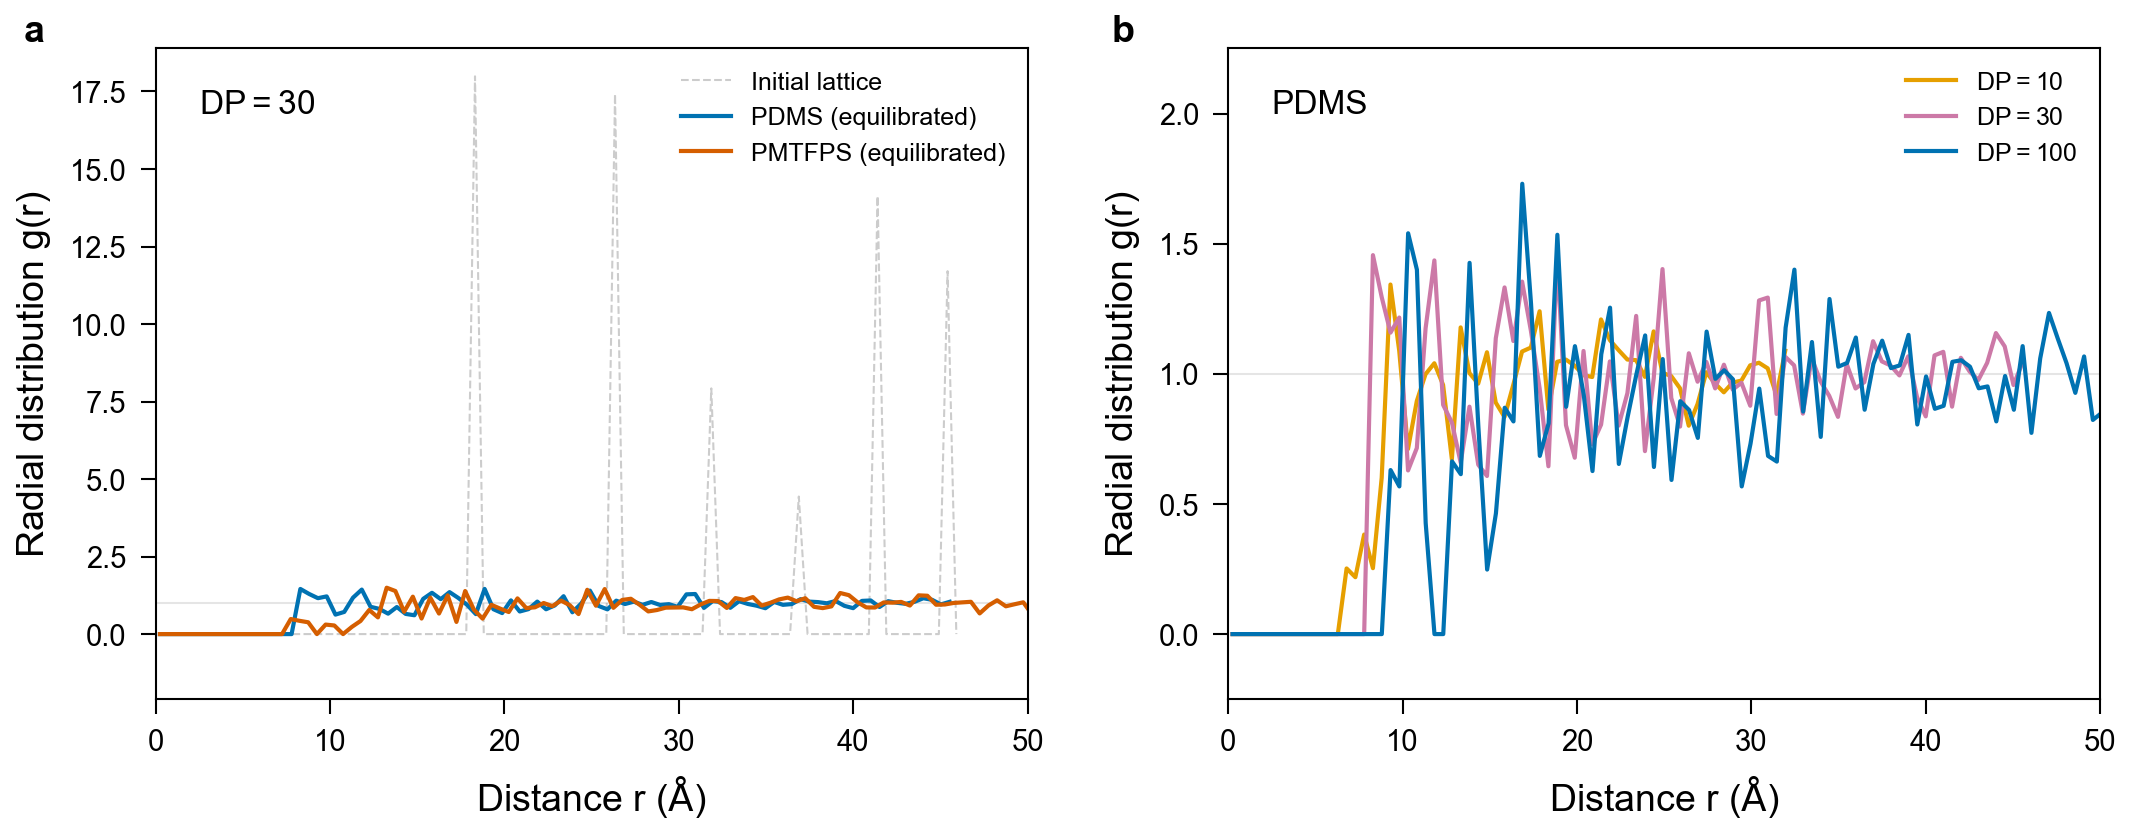

In [2]:
# --- Figure 1: RDF ---
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
import sys
sys.path.append(os.path.abspath('data'))
from npj_style_v1 import set_npj_style, add_panel_label

os.makedirs(output_dir, exist_ok=True)

width, _ = set_npj_style(column_type='double')
height = width * 0.4 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width, height), constrained_layout=True)

with open(os.path.join(DATA_PATH, 'dataset.pkl'), 'rb') as f:
    dataset = pickle.load(f)
    db = dataset['analysis']

# --- Panel a: Crosslinker-Crosslinker RDF ---
target_dp = 'DP_30'
colors = {'PDMS': '#0072B2', 'PMTFPS': '#D55E00'} 

if target_dp in db['PDMS']:
    bins_c, gr_c = db['PDMS'][target_dp]['rdf_crystal']
    if bins_c is not None:
        ax1.plot(bins_c, gr_c, color='gray', linestyle='--', linewidth=0.5, 
                 alpha=0.4, label='Initial lattice')

for chem in ['PDMS', 'PMTFPS']:
    if target_dp in db[chem]:
        bins, gr = db[chem][target_dp]['rdf_amorphous']
        if bins is not None:
            label_text = f"{chem} (equilibrated)"
            ax1.plot(bins, gr, lw=1.0, color=colors.get(chem, 'k'), label=label_text)

ax1.set_xlabel(r'Distance $r$ ($\mathrm{\AA}$)')
ax1.set_ylabel(r'Radial distribution $g(r)$') # Updated Y-label
ax1.set_xlim(0, 50)
ax1.legend(frameon=False, loc='upper right')

ax1.text(0.05, 0.9, r'$DP=30$', transform=ax1.transAxes, fontsize=8)

# --- Panel b: Effect of Chain Length ---
chem = 'PDMS'
dp_colors = {'DP_10': '#E69F00', 'DP_30': '#CC79A7', 'DP_100': '#0072B2'}

for dp in ['DP_10', 'DP_30', 'DP_100']:
    if dp in db[chem]:
        bins, gr = db[chem][dp]['rdf_amorphous']
        if bins is not None:
            dp_val = dp.split('_')[1]
            label_clean = fr'$DP={dp_val}$'
            ax2.plot(bins, gr, lw=1.0, color=dp_colors.get(dp, 'k'), label=label_clean)

ax2.set_xlabel(r'Distance $r$ ($\mathrm{\AA}$)')
ax2.set_ylabel(r'Radial distribution $g(r)$') # Updated Y-label
ax2.set_xlim(0, 50)
ax2.set_ylim(-0.25, 2.25)
ax2.legend(frameon=False, loc='upper right')

ax2.text(0.05, 0.9, 'PDMS', transform=ax2.transAxes, fontsize=8)

# --- Zero-Line Alignment ---
y2_min, y2_max = ax2.get_ylim()
zero_ratio = (0 - y2_min) / (y2_max - y2_min)
y1_min, y1_max = ax1.get_ylim()
new_y1_min = - (zero_ratio * y1_max) / (1 - zero_ratio)
ax1.set_ylim(new_y1_min, y1_max)

# --- Alignment Logic ---
fig.canvas.draw()

def align_label_to_ylabel(ax, label_text):
    ylabel = ax.yaxis.label
    bbox = ylabel.get_window_extent(renderer=fig.canvas.get_renderer())
    ylabel_center_x = (bbox.x0 + bbox.x1) / 2

    ax_bbox = ax.get_window_extent()
    ax_width = ax_bbox.width

    x_rel = (ylabel_center_x - ax_bbox.x0) / ax_width

    ax.text(x_rel, 1.0, label_text, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='bottom', ha='center')

align_label_to_ylabel(ax1, 'a')
align_label_to_ylabel(ax2, 'b')

ax1.axhline(1, color='black', linewidth=0.5, alpha=0.1, zorder=0)
ax2.axhline(1, color='black', linewidth=0.5, alpha=0.1, zorder=0)

plt.savefig(os.path.join(output_dir, 'Figure_1_RDF.pdf'), dpi=SAVE_DPI)   # CHANGE (v0.2.0): the manuscript includes the PDF
plt.savefig(os.path.join(output_dir, 'Figure_1_RDF.png'), dpi=SAVE_DPI)
print("Figure 1 re-generated with dynamic label alignment.")

Figure 2 generated successfully.


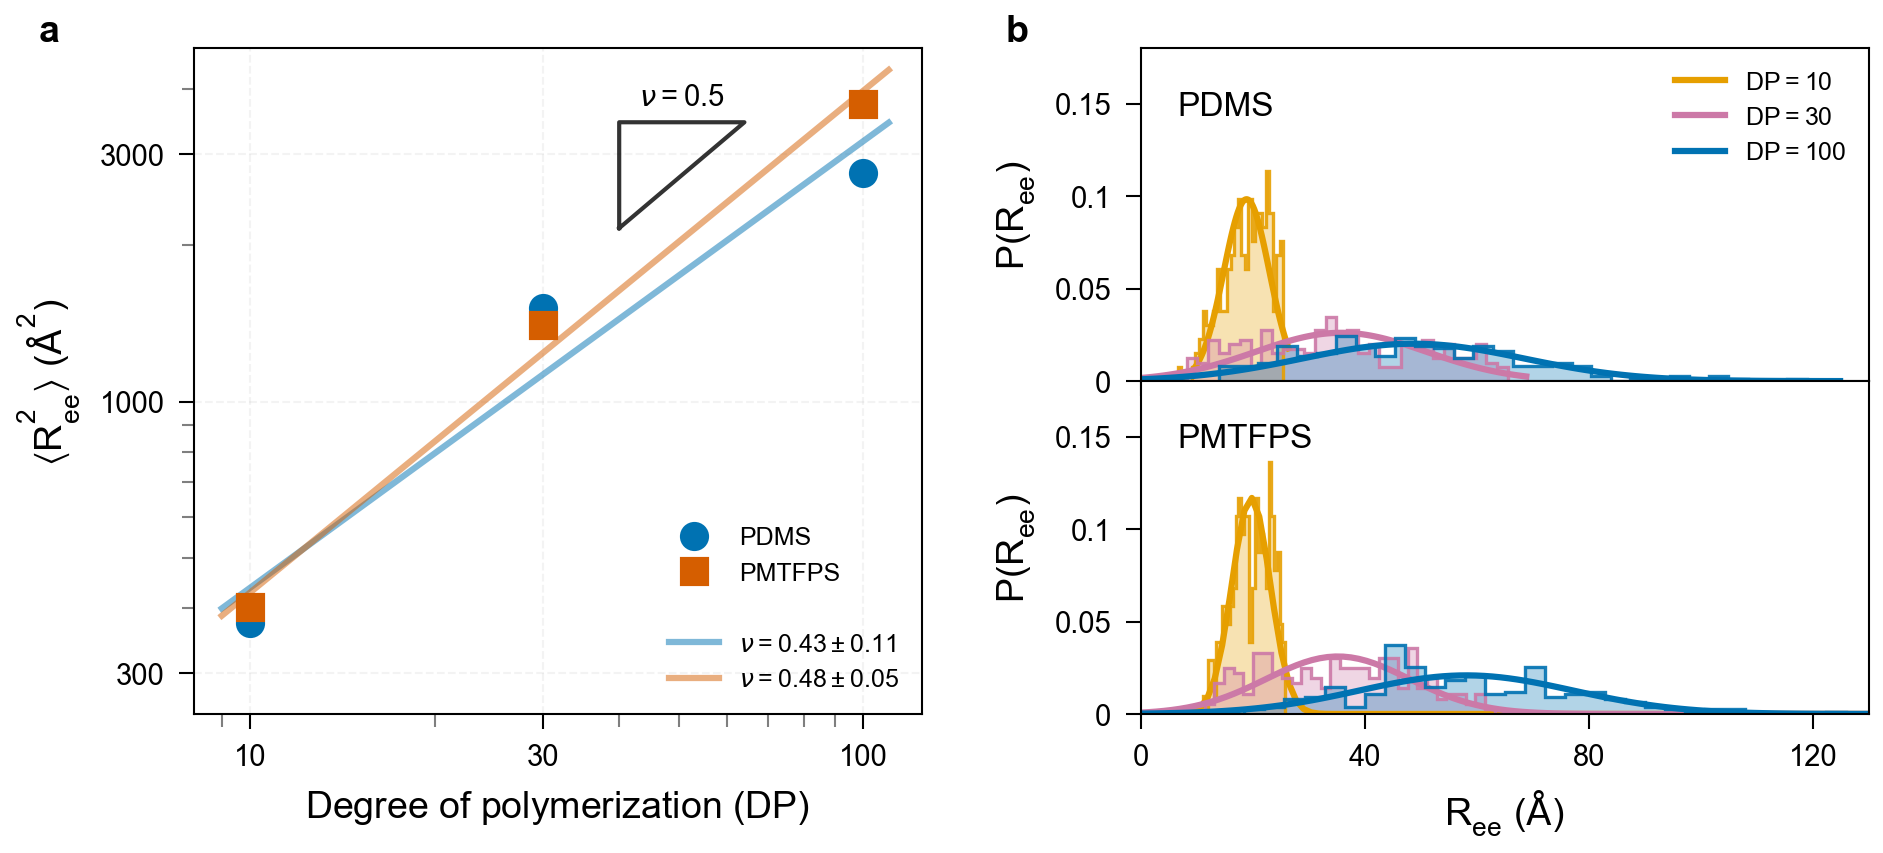

In [3]:
# --- Figure 2: Scaling ---
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
import sys
from scipy.stats import norm

sys.path.append(os.path.abspath('data'))
from npj_style_v1 import set_npj_style

os.makedirs(output_dir, exist_ok=True)

width, _ = set_npj_style(column_type='double')
height = width * 0.40 

plt.rcParams['figure.constrained_layout.use'] = False

fig = plt.figure(figsize=(width, height), constrained_layout=False)
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1, 1], 
                       wspace=0.3, hspace=0)

ax_scaling = fig.add_subplot(gs[:, 0])      # Left: Scaling
ax_dist_top = fig.add_subplot(gs[0, 1])     # Right Top: PDMS Dist
ax_dist_bot = fig.add_subplot(gs[1, 1], sharex=ax_dist_top) # Right Bot: FPDMS Dist

with open(os.path.join(DATA_PATH, 'dataset.pkl'), 'rb') as f:
    dataset = pickle.load(f)
db = dataset['analysis']

# --- CONFIG ---
dps = ['DP_10', 'DP_30', 'DP_100']
colors = {'DP_10': '#E69F00', 'DP_30': '#CC79A7', 'DP_100': '#0072B2'}

def get_data(chem, dp):
    if chem in db and dp in db[chem]:
        try:
            return db[chem][dp]['ree_data'], db[chem][dp]['rg_data']
        except (KeyError, TypeError):
             return [], []
    return [], []

# =============================================================================
# =============================================================================
chem_styles = {'PDMS': {'c': '#0072B2', 'fmt': 'o'}, 'PMTFPS': {'c': '#D55E00', 'fmt': 's'}}

handles_data = []
handles_fits = []

for chem in ['PDMS', 'PMTFPS']:
    N_vals = []
    R2_vals = []
    for dp in dps:
        ree_vals, _ = get_data(chem, dp)
        if len(ree_vals) > 0:
            actual_N = int(dp.split('_')[1])
            N_vals.append(actual_N)
            R2_vals.append(np.mean(ree_vals**2))

    if len(N_vals) > 0:
        style = chem_styles[chem]
        h_data, = ax_scaling.loglog(N_vals, R2_vals, style['fmt'], color=style['c'], label=f'{chem}', markersize=6)
        handles_data.append(h_data)

        if len(N_vals) > 1:
            log_N = np.log(N_vals)
            log_R2 = np.log(R2_vals)
            (slope, intercept), cov = np.polyfit(log_N, log_R2, 1, cov=True)
            nu = slope / 2

            err_slope = np.sqrt(np.diag(cov))[0]
            err_nu = err_slope / 2

            x_fit = np.linspace(min(N_vals)*0.9, max(N_vals)*1.1, 10)
            y_fit = np.exp(intercept) * x_fit**slope
            h_fit, = ax_scaling.loglog(x_fit, y_fit, '-', color=style['c'], alpha=0.5, lw=1.5, 
                       label=fr'$\mathit{{\nu}}={nu:.2f}\pm{err_nu:.2f}$')
            handles_fits.append(h_fit)

from matplotlib.patches import Rectangle
h_spacer = Rectangle((0,0), 1, 1, fill=False, edgecolor='none', visible=False, label='')

final_handles = handles_data + [h_spacer] + handles_fits
ax_scaling.legend(handles=final_handles, frameon=False, loc='lower right', ncol=1)

tri_x_start = 40 
tri_y_start = 12 * 40**(1.0) * 4.5 # nudge up (3.5 -> 4.5)
tri_size = 1.6 

x0, y0 = tri_x_start, tri_y_start
x1 = tri_x_start * tri_size
y1 = tri_y_start * tri_size**1.0 # Slope 1

tx = [x0, x0, x1, x0]
ty = [y0, y1, y1, y0]

ax_scaling.loglog(tx, ty, 'k-', lw=1.0, alpha=0.8)

label_x = np.sqrt(x0 * x1)
label_y = y1 * 1.05 # Lowered (1.15 -> 1.05)
ax_scaling.text(label_x, label_y, r'$\mathit{\nu}=0.5$', 
                fontsize=7, ha='center', va='bottom')

ax_scaling.grid(True, which='major', linestyle='--', alpha=0.15, linewidth=0.5)

import matplotlib.ticker as ticker
ax_scaling.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax_scaling.set_yticks([300, 1000, 3000])
ax_scaling.get_yaxis().set_major_formatter(ticker.ScalarFormatter())
ax_scaling.set_ylim(250, 4800) 

ax_scaling.set_xticks([10, 30, 100])
ax_scaling.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax_scaling.set_xlim(left=8.1)

ax_scaling.minorticks_on()
minor_subs = [2, 3, 4, 5, 6, 7, 8, 9]
ax_scaling.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=minor_subs, numticks=100))
ax_scaling.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=minor_subs, numticks=100))
ax_scaling.tick_params(which='minor', length=3, color=(0,0,0,0.5), width=0.5)

ax_scaling.set_xlabel(r'Degree of polymerization ($DP$)') # Fixed N -> DP
ax_scaling.set_ylabel(r'$\langle R_{ee}^2 \rangle$ ($\mathrm{\AA}^2$)')

# =============================================================================
# =============================================================================

def plot_distributions(ax, chem_name, hide_xlabel=False):
    ax.text(0.05, 0.8, chem_name, transform=ax.transAxes, fontsize=8)

    for dp in dps:
        ree_data, _ = get_data(chem_name, dp)
        if len(ree_data) > 0:
            dp_val = dp.split('_')[1]
            label_clean = fr'$DP={dp_val}$'

            # CHANGE (Oct 2026): histograms drawn as filled bars so the shape of each distribution stays visible
            ax.hist(ree_data, bins=30, density=True, histtype='stepfilled',
                    linewidth=0, color=colors[dp], alpha=0.30)
            ax.hist(ree_data, bins=30, density=True, histtype='step',
                    linewidth=0.8, color=colors[dp], alpha=0.9)

            mu, std = norm.fit(ree_data)
            xmin, xmax = ax.get_xlim()
            if xmax <= 1.0: xmin, xmax = 0, max(ree_data)*1.1
            x = np.linspace(0, xmax, 100)
            p = norm.pdf(x, mu, std)
            ax.plot(x, p, '-', linewidth=1.5, color=colors[dp], label=label_clean)

    ax.set_yticks([0, 0.05, 0.1, 0.15])
    ax.set_yticklabels(['0', '0.05', '0.1', '0.15'])
    ax.set_ylabel(r'$P(R_{ee})$')
    ax.set_ylim(0, 0.18)

    if hide_xlabel:
        ax.tick_params(axis='x', labelbottom=False) 
    else:
        ax.set_xlabel(r'$R_{ee}$ ($\mathrm{\AA}$)')
        ax.set_xticks([0, 40, 80, 120])
        ax.set_xticklabels(['0', '40', '80', '120'])
        ax.set_xlim(0, 130)

plot_distributions(ax_dist_top, 'PDMS', hide_xlabel=True)
ax_dist_top.legend(frameon=False, loc='upper right')

plot_distributions(ax_dist_bot, 'PMTFPS', hide_xlabel=False)

# --- Alignment Logic ---
fig.canvas.draw()

def align_label_to_ylabel(ax, label_text):
    ylabel = ax.yaxis.label
    bbox = ylabel.get_window_extent(renderer=fig.canvas.get_renderer())
    ylabel_center_x = (bbox.x0 + bbox.x1) / 2

    ax_bbox = ax.get_window_extent()
    ax_width = ax_bbox.width

    x_rel = (ylabel_center_x - ax_bbox.x0) / ax_width

    ax.text(x_rel, 1.0, label_text, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='bottom', ha='center')

align_label_to_ylabel(ax_scaling, 'a')
align_label_to_ylabel(ax_dist_top, 'b')

plt.savefig(os.path.join(output_dir, 'Figure_2_Scaling_and_Distributions.pdf'), dpi=SAVE_DPI)   # CHANGE (v0.2.0): the manuscript includes the PDF
plt.savefig(os.path.join(output_dir, 'Figure_2_Scaling_and_Distributions.png'), dpi=SAVE_DPI)
print("Figure 2 generated successfully.")

Figure 3 generated successfully.


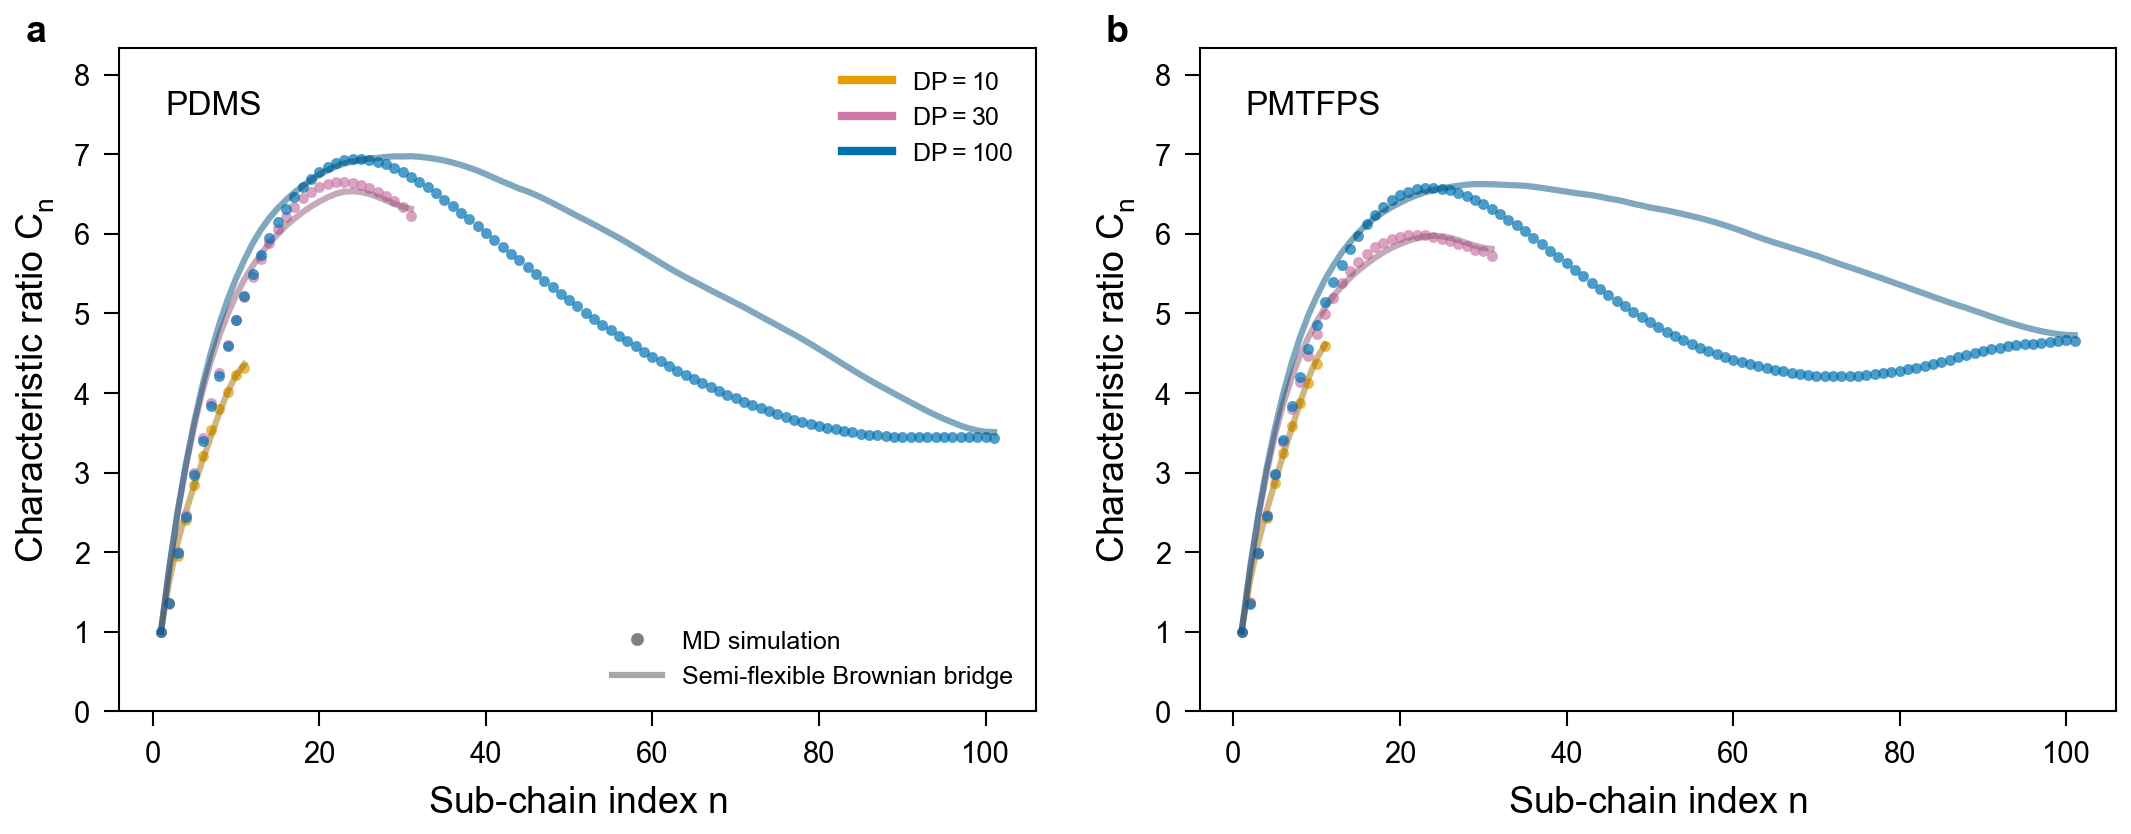

In [4]:
# --- Figure 3: Characteristic Ratio ---
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
import sys

sys.path.append(os.path.abspath('data'))
from npj_style_v1 import set_npj_style

os.makedirs(output_dir, exist_ok=True)

# CHANGE (v0.2.0): fixed seed for the Brownian-bridge sampling (the published figure had none; with this seed the
# model curves lie within Monte Carlo noise of the published ones)
np.random.seed(20260924)

width, _ = set_npj_style(column_type='double')
height = width * 0.4 

plt.rcParams['figure.constrained_layout.use'] = True
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width, height), constrained_layout=True)

# ---------------------------------------------------------
# ---------------------------------------------------------
def generate_semiflexible_walks(n_samples, n_steps, c_inf=1.0):
    vecs = np.zeros((n_samples, int(n_steps), 3))
    v0 = np.random.randn(n_samples, 3)
    v0 /= np.linalg.norm(v0, axis=1, keepdims=True)
    vecs[:, 0, :] = v0

    if c_inf <= 1.0 + 1e-5:
        for i in range(1, int(n_steps)):
            v = np.random.randn(n_samples, 3)
            v /= np.linalg.norm(v, axis=1, keepdims=True)
            vecs[:, i, :] = v
    else:
        cos_theta = (c_inf - 1) / (c_inf + 1)
        sin_theta = np.sqrt(1 - cos_theta**2)

        for i in range(1, int(n_steps)):
            w = vecs[:, i-1, :]
            phi = np.random.uniform(0, 2*np.pi, n_samples)
            r = np.random.randn(n_samples, 3)
            u = np.cross(r, w)
            u_norms = np.linalg.norm(u, axis=1, keepdims=True)

            mask_zero = u_norms.flatten() < 1e-6
            if np.any(mask_zero):
                u[mask_zero] = np.cross([1,0,0], w[mask_zero])
                u_norms[mask_zero] = np.linalg.norm(u[mask_zero], axis=1, keepdims=True)

            u /= u_norms
            v = np.cross(w, u)

            step = sin_theta * (np.cos(phi)[:, None] * u + np.sin(phi)[:, None] * v) + cos_theta * w
            step /= np.linalg.norm(step, axis=1, keepdims=True)
            vecs[:, i, :] = step

    return vecs

def simulate_bridge_ensemble(N_steps, target_Ree_b, c_inf=1.0, tolerance=0.15, n_samples=20000):
    vecs = generate_semiflexible_walks(n_samples, N_steps, c_inf=c_inf)
    paths = np.zeros((n_samples, int(N_steps)+1, 3))
    paths[:, 1:, :] = np.cumsum(vecs, axis=1)

    ree_vectors = paths[:, -1, :] - paths[:, 0, :]
    ree_dists = np.linalg.norm(ree_vectors, axis=1)

    active_tol = tolerance
    mask = (ree_dists >= target_Ree_b * (1 - active_tol)) & \
           (ree_dists <= target_Ree_b * (1 + active_tol))

    if np.sum(mask) < 200:
        active_tol = 0.25
        mask = (ree_dists >= target_Ree_b * (1 - active_tol)) & \
               (ree_dists <= target_Ree_b * (1 + active_tol))

    if np.sum(mask) < 10: return None, None

    constrained_paths = paths[mask]
    dists_sq = np.sum(constrained_paths[:, 1:, :]**2, axis=2)
    mean_dists_sq = np.mean(dists_sq, axis=0)
    n_axis = np.arange(1, int(N_steps) + 1)

    return n_axis, mean_dists_sq / n_axis

# ---------------------------------------------------------
# ---------------------------------------------------------
with open(os.path.join(DATA_PATH, 'dataset.pkl'), 'rb') as f:
    dataset = pickle.load(f)
    db = dataset['analysis']

dps = ['DP_10', 'DP_30', 'DP_100']
dps = ['DP_10', 'DP_30', 'DP_100']
colors = {'DP_10': '#E69F00', 'DP_30': '#CC79A7', 'DP_100': '#0072B2'} 
fit_colors = {'DP_10': '#a16f00', 'DP_30': '#8f5575', 'DP_100': '#00507d'} 
manual_cinf_pdms = {'DP_10': 4.5, 'DP_30': 9.0, 'DP_100': 9.25}
manual_cinf_ptfpms = {'DP_10': 4.5, 'DP_30': 8.0, 'DP_100': 8.5}

# ---------------------------------------------------------
# ---------------------------------------------------------
def plot_bridge_panel(ax, chem_name, stiffness_dict):
    max_y = 0
    for dp in dps:
        if dp in db[chem_name]:
            n_data, msid = db[chem_name][dp]['msid_data']
            ree_data = db[chem_name][dp]['ree_data']

            if n_data is not None:
                b = np.sqrt(msid[0]) if msid[0] > 0 else 1.5
                cn_data = msid / (n_data * b**2)
                max_y = max(max_y, np.max(cn_data))

                dp_val = dp.split('_')[1]
                label_latex = fr'$DP={dp_val}$'

                ax.plot(n_data, cn_data, 'o', markersize=2.5, alpha=0.7, markeredgewidth=0.1,
                        color=colors[dp], label=label_latex)

                rms_ree_b = np.sqrt(np.mean(ree_data**2)) / b
                user_c = stiffness_dict[dp]

                s_n, s_cn = simulate_bridge_ensemble(n_data[-1], rms_ree_b, 
                                                     c_inf=user_c, n_samples=40000) 

                if s_n is not None:
                    ax.plot(s_n, s_cn, '-', lw=1.5, alpha=0.5, color=fit_colors.get(dp, colors[dp]))

    ax.set_xlabel(r'Sub-chain index $n$') # Keeps n, but ensures font matches
    return max_y

ymax1 = plot_bridge_panel(ax1, 'PDMS', manual_cinf_pdms)
ymax2 = plot_bridge_panel(ax2, 'PMTFPS', manual_cinf_ptfpms)

global_max = max(ymax1, ymax2)
ax1.set_ylim(0, global_max * 1.2)
ax2.set_ylim(0, global_max * 1.2)

ax1.set_ylabel(r'Characteristic ratio $C_n$')
ax2.set_ylabel(r'Characteristic ratio $C_n$') 

# ---------------------------------------------------------
# ---------------------------------------------------------

ax1.text(0.05, 0.9, 'PDMS', transform=ax1.transAxes, fontsize=8)
ax2.text(0.05, 0.9, 'PMTFPS', transform=ax2.transAxes, fontsize=8)

from matplotlib.lines import Line2D

style_handles = [
    Line2D([0], [0], marker='o', linestyle='none', color='gray',
           markersize=3, markeredgewidth=0.1, label='MD simulation'),
    Line2D([0], [0], color='gray', lw=1.5, alpha=0.7,
           label='Semi-flexible Brownian bridge'),
]
color_handles = [
    Line2D([0], [0], color=colors[dp], lw=2,
           label=fr'$DP={dp.split("_")[1]}$') for dp in dps
]

leg_style = ax1.legend(handles=style_handles, frameon=False,
                       loc='lower right', fontsize=6)
ax1.add_artist(leg_style)
ax1.legend(handles=color_handles, frameon=False,
           loc='upper right', fontsize=6)

def align_label_to_ylabel(ax, label_text):
    fig.canvas.draw()

    ylabel = ax.yaxis.label
    bbox = ylabel.get_window_extent(renderer=fig.canvas.get_renderer())
    ylabel_center_x = (bbox.x0 + bbox.x1) / 2

    ax_bbox = ax.get_window_extent()
    ax_width = ax_bbox.width

    x_rel = (ylabel_center_x - ax_bbox.x0) / ax_width

    ax.text(x_rel, 1.0, label_text, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='bottom', ha='center')

align_label_to_ylabel(ax1, 'a')
align_label_to_ylabel(ax2, 'b')

plt.savefig(os.path.join(output_dir, 'Figure_3_Characteristic_Ratio.pdf'), dpi=SAVE_DPI)   # CHANGE (v0.2.0): the manuscript includes the PDF
plt.savefig(os.path.join(output_dir, 'Figure_3_Characteristic_Ratio.png'), dpi=SAVE_DPI)
print("Figure 3 generated successfully.")

Figure 4 generated successfully (Figure_4_Tg).
lag 4 ps: Tg of the history-averaged curve +/- SD of the three per-history Tg  [per-history Tg]
  PDMS   DP_10    150.1 +/- 13.8   [150.7, 136.8, 164.3]
  PDMS   DP_30    164.5 +/-  5.6   [159.0, 168.0, 169.3]
  PDMS   DP_100   153.5 +/-  2.5   [152.0, 153.1, 156.8]
  PMTFPS DP_10    186.4 +/-  7.5   [195.6, 180.7, 190.1]
  PMTFPS DP_30    191.1 +/-  3.7   [191.7, 195.0, 187.7]
  PMTFPS DP_100   191.8 +/-  2.3   [191.6, 191.3, 195.4]
  labels match the manuscript figure
  original history vs deposited tg_msd.csv: 252 temperatures, max |difference| 8.9e-16 A^2 (averaging order)


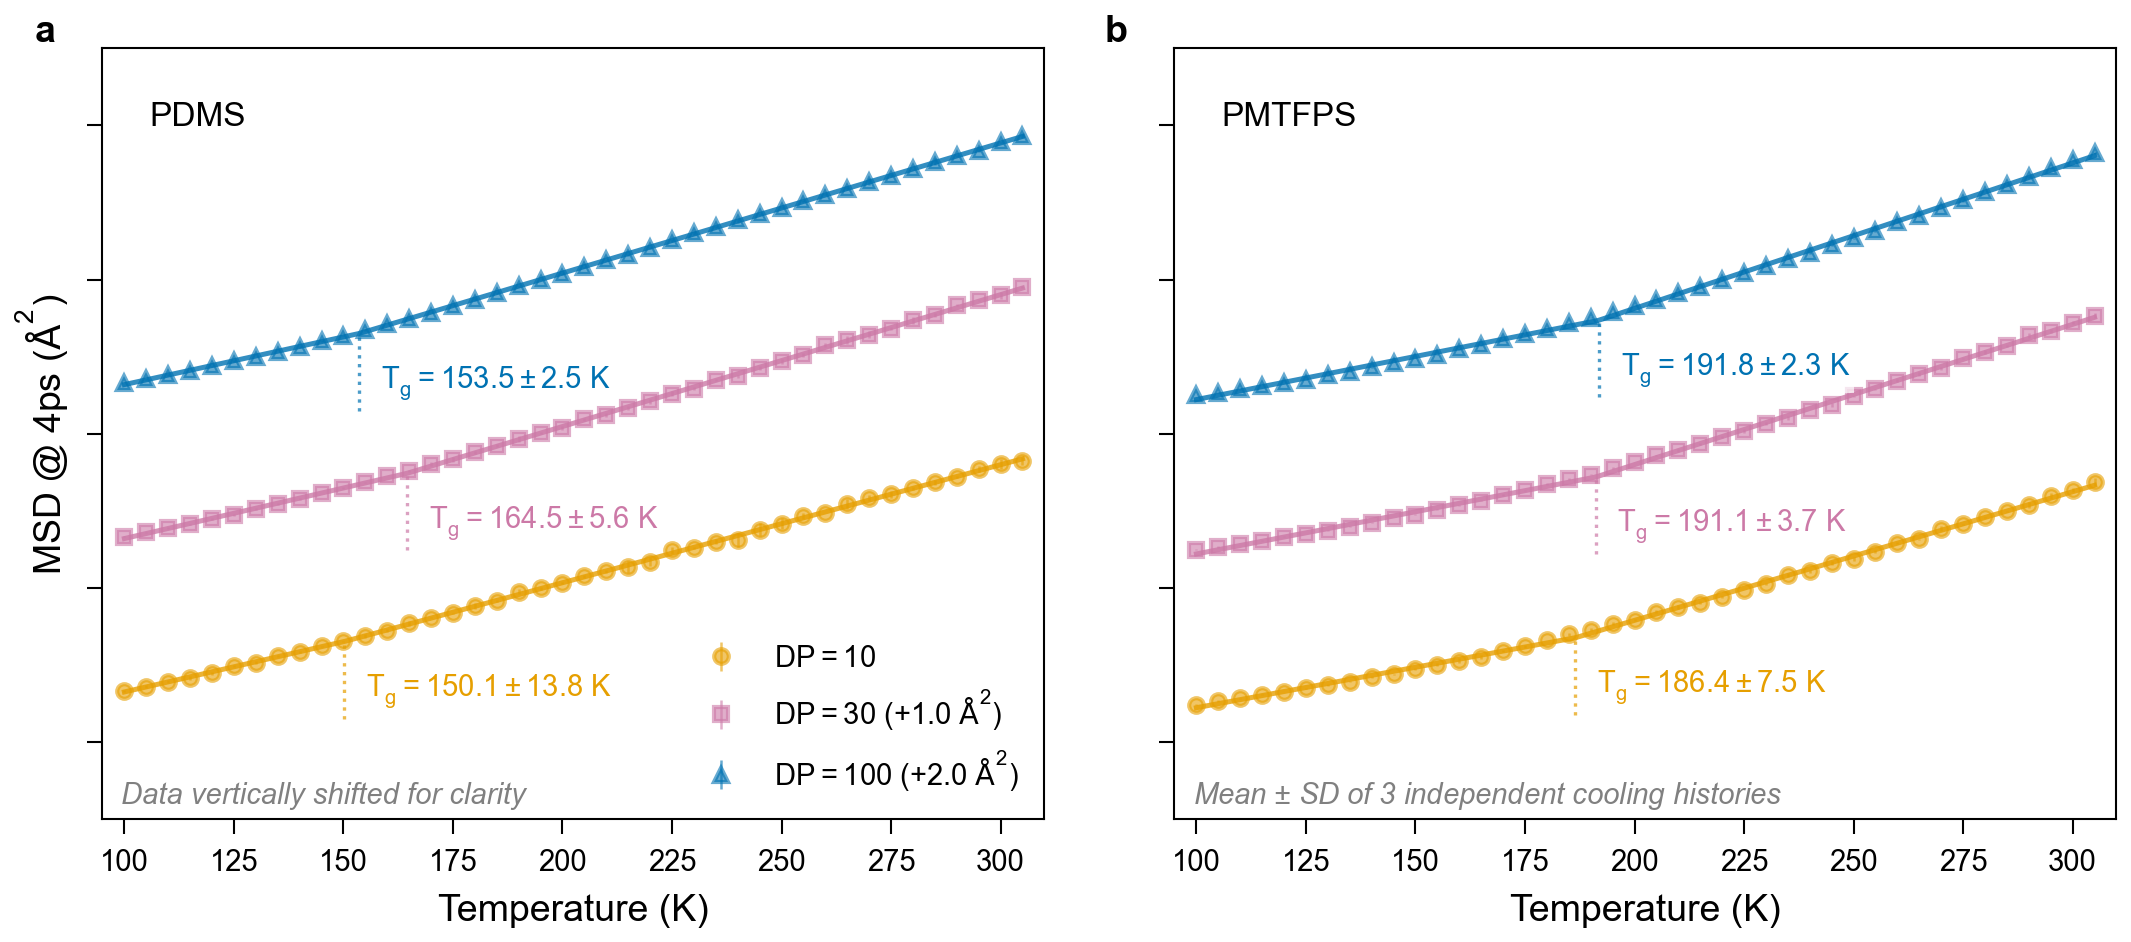

In [5]:
# --- Figure 4: Tg ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import os
import sys
from scipy.optimize import curve_fit

sys.path.append(os.path.abspath('data'))
from npj_style_v1 import set_npj_style

os.makedirs(output_dir, exist_ok=True)

# CHANGE (v0.2.0): MSD lag (ps) used for Tg. The manuscript uses 4 ps; any integer 1-10 works (other lags are
# saved as Figure_4_Tg_<lag>ps so the manuscript file is not overwritten)
TG_LAG = 4

width, _ = set_npj_style(column_type='double')
height = width * 0.45 

plt.rcParams['figure.constrained_layout.use'] = True
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width, height), constrained_layout=True)

# ---------------------------------------------------------
# ---------------------------------------------------------
def piecewise_linear(T, Tg, m1, m2, c1):
    condlist = [T < Tg, T >= Tg]
    funclist = [
        lambda x: m1 * x + c1,
        lambda x: m2 * (x - Tg) + (m1 * Tg + c1)
    ]
    return np.piecewise(T, condlist, funclist)

def get_optimized_bilinear_tg(temp, msd, guess_tg=150):
    try:
        p0 = [guess_tg, 0.005, 0.02, np.min(msd)]
        bounds = ([np.min(temp)+5, -np.inf, -np.inf, -np.inf], 
                  [np.max(temp)-5, np.inf, np.inf, np.inf])
        popt, pcov = curve_fit(piecewise_linear, temp, msd, p0=p0, bounds=bounds, maxfev=10000)
        return popt[0], (popt, pcov)
    except:
        return np.nan, None

# ---------------------------------------------------------
# ---------------------------------------------------------
# CHANGE (v0.2.0): three independent cooling histories per system (the original run and replicates 2 and 3),
# data/derived/tg/tg_msd_histories.csv. Points = mean over the histories, error bars = SD across them, line = the
# two-slope fit of the mean curve, label = its Tg +/- SD of the three per-history Tg. The mock-data generator is removed.
db_real = read_csv_exact(os.path.join(REV_PATH, 'tg', 'tg_msd_histories.csv'))
histories = ['original', 'replicate2', 'replicate3']
guesses = {'PDMS': 150, 'PMTFPS': 200}

db = {}
for chem in ['PDMS', 'PMTFPS']:
    db[chem] = {}
    for dp in ['DP_10', 'DP_30', 'DP_100']:
        sub = db_real[(db_real['system'] == chem) & (db_real['dp'] == int(dp.split('_')[1]))]
        per = [sub[sub['history'] == h].set_index('Temp')[f'MSD_{TG_LAG}ps'] for h in histories]
        if any(len(p) == 0 for p in per):
            raise ValueError(f'tg_msd_histories.csv has no data for {chem} {dp} in one of {histories}')
        temps_common = sorted(set.intersection(*[set(p.index) for p in per]))   # temperatures present in all histories
        msd_h = np.array([[p[t] for t in temps_common] for p in per])            # (3 histories, n temperatures)
        temps = np.array(temps_common, float)
        tg_h = [get_optimized_bilinear_tg(temps, m, guess_tg=guesses[chem])[0] for m in msd_h]
        tg_val, params = get_optimized_bilinear_tg(temps, msd_h.mean(0), guess_tg=guesses[chem])
        db[chem][dp] = dict(T=temps, mean=msd_h.mean(0), sd=msd_h.std(0, ddof=1), tg=tg_val, params=params,
                            tg_h=tg_h, tg_sd=float(np.std(tg_h, ddof=1)))

dps = ['DP_10', 'DP_30', 'DP_100']
colors = {'DP_10': '#E69F00', 'DP_30': '#CC79A7', 'DP_100': '#0072B2'}
markers = {'DP_10': 'o', 'DP_30': 's', 'DP_100': '^'}

# ---------------------------------------------------------
# ---------------------------------------------------------
def plot_tg_panel(ax, chem_name, guess_tg):
    ax.text(0.05, 0.9, chem_name, transform=ax.transAxes, fontsize=8)

    shift_step = 1.0 # Vertical shift amount in Angstrom^2

    for i, dp in enumerate(dps):
        if dp in db[chem_name]:
            r = db[chem_name][dp]
            temps = r['T']
            y_offset = i * shift_step

            tg_val, params = r['tg'], r['params']

            dp_val = dp.split('_')[1]
            base_label = fr'$DP={dp_val}$'
            label_final = f"{base_label} (+{y_offset} $\\mathrm{{\\AA}}^2$)" if i>0 else base_label

            # CHANGE (v0.2.0): mean over the three histories with SD error bars
            ax.errorbar(temps, r['mean'] + y_offset, yerr=r['sd'], marker=markers[dp], linestyle='None',
                        color=colors[dp], alpha=0.6, markersize=3.5, elinewidth=0.6, capsize=0, label=label_final)

            if params is not None:
                t_fit = np.linspace(min(temps), max(temps), 200)
                msd_fit = piecewise_linear(t_fit, *params[0]) # params[0] is popt
                ax.plot(t_fit, msd_fit + y_offset, '-', color=colors[dp], linewidth=1.2, alpha=0.8)

                y_at_tg = piecewise_linear(tg_val, *params[0]) + y_offset

                ax.vlines(tg_val, y_at_tg - 0.5, y_at_tg + 0,
                          color=colors[dp], linestyle=':', linewidth=0.8, alpha=0.7)

                text_y_offset = -0.35
                # CHANGE (v0.2.0): +/- = SD of the three per-history Tg (was the curve_fit standard error)
                ax.text(tg_val + 5, y_at_tg + text_y_offset, fr"$T_g={tg_val:.1f}\pm{r['tg_sd']:.1f}$ K",
                        color=colors[dp], fontsize=7,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    ax.set_xlabel('Temperature (K)')
    ax.set_xlim(95, 310)
    ax.yaxis.set_tick_params(left=True, labelleft=False)
    ax.set_ylim(bottom=-0.5, top=4.5)

plot_tg_panel(ax1, 'PDMS', guess_tg=150)
ax1.set_ylabel(fr'MSD @ {TG_LAG}ps ($\mathrm{{\AA}}^2$)')   # CHANGE (v0.2.0): lag from TG_LAG
ax1.text(0.02, 0.02, 'Data vertically shifted for clarity', transform=ax1.transAxes, 
         fontsize=7, fontstyle='italic', color='grey')

ax1.legend(frameon=False, loc='lower right', fontsize=7)

plot_tg_panel(ax2, 'PMTFPS', guess_tg=200)
ax2.text(0.02, 0.02, r'Mean $\pm$ SD of 3 independent cooling histories',   # CHANGE (v0.2.0)
         transform=ax2.transAxes, fontsize=7, fontstyle='italic', color='grey')

def align_label_to_ylabel(ax, label_text):
    fig.canvas.draw()

    ylabel = ax.yaxis.label
    bbox = ylabel.get_window_extent(renderer=fig.canvas.get_renderer())
    ylabel_center_x = (bbox.x0 + bbox.x1) / 2

    ax_bbox = ax.get_window_extent()
    ax_width = ax_bbox.width

    x_rel = (ylabel_center_x - ax_bbox.x0) / ax_width

    ax.text(x_rel, 1.0, label_text, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='bottom', ha='center')

align_label_to_ylabel(ax1, 'a')
ax2.text(-0.05, 1.0, 'b', transform=ax2.transAxes, fontsize=9, fontweight='bold', va='bottom', ha='right')

tg_stem = 'Figure_4_Tg' if TG_LAG == 4 else f'Figure_4_Tg_{TG_LAG}ps'
# CHANGE (v0.2.0): PDF as in the manuscript; fig.savefig, PDF then PNG, as in the script that made the
# manuscript file (plt.savefig redraws the figure between the saves and moves the layout by a fraction of a point)
fig.savefig(os.path.join(output_dir, f'{tg_stem}.pdf'), dpi=SAVE_DPI)
fig.savefig(os.path.join(output_dir, f'{tg_stem}.png'), dpi=SAVE_DPI)
print(f"Figure 4 generated successfully ({tg_stem}).")

# CHANGE (v0.2.0): checks
print(f"lag {TG_LAG} ps: Tg of the history-averaged curve +/- SD of the three per-history Tg  [per-history Tg]")
for chem in ['PDMS', 'PMTFPS']:
    for dp in dps:
        r = db[chem][dp]
        print(f"  {chem:7s}{dp:7s} {r['tg']:6.1f} +/- {r['tg_sd']:4.1f}   [" + ", ".join(f"{v:.1f}" for v in r['tg_h']) + "]")
if TG_LAG == 4:   # labels of the manuscript figure
    expected = {('PDMS', 'DP_10'): '150.1+/-13.8', ('PDMS', 'DP_30'): '164.5+/-5.6', ('PDMS', 'DP_100'): '153.5+/-2.5',
                ('PMTFPS', 'DP_10'): '186.4+/-7.5', ('PMTFPS', 'DP_30'): '191.1+/-3.7', ('PMTFPS', 'DP_100'): '191.8+/-2.3'}
    got = {k: f"{db[k[0]][k[1]]['tg']:.1f}+/-{db[k[0]][k[1]]['tg_sd']:.1f}" for k in expected}
    assert got == expected, got
    print('  labels match the manuscript figure')
# the 'original' history is the deposited data/csv/tg_msd.csv (the dataset.pkl values used in the submission)
dep = read_csv_exact(os.path.join(DATA_PATH, 'csv', 'tg_msd.csv'))
orig = db_real[db_real['history'] == 'original'].merge(dep, on=['system', 'dp', 'Temp'], suffixes=('', '_dep'))
assert len(orig) == len(dep)
dmax = max((orig[f'MSD_{k}ps'] - orig[f'MSD_{k}ps_dep']).abs().max() for k in range(1, 11))
print(f"  original history vs deposited tg_msd.csv: {len(orig)} temperatures, max |difference| {dmax:.1e} A^2 (averaging order)")
assert dmax < 1e-14

Loaded dataset.pkl + derived/mechanics/mechanics_pulls_4seeds.csv with shape (327, 38)
quadrant sizes (12-pull means): {'Q1: Weak/Brittle': 128, 'Q2: Weak/Tough': 35, 'Q3: Strong/Brittle': 35, 'Q4: Strong/Tough': 129}


Figure 5 generated successfully.
Figure 5b bands vs figure5b_degree_bands_k12.csv: max |difference| = 0.0e+00


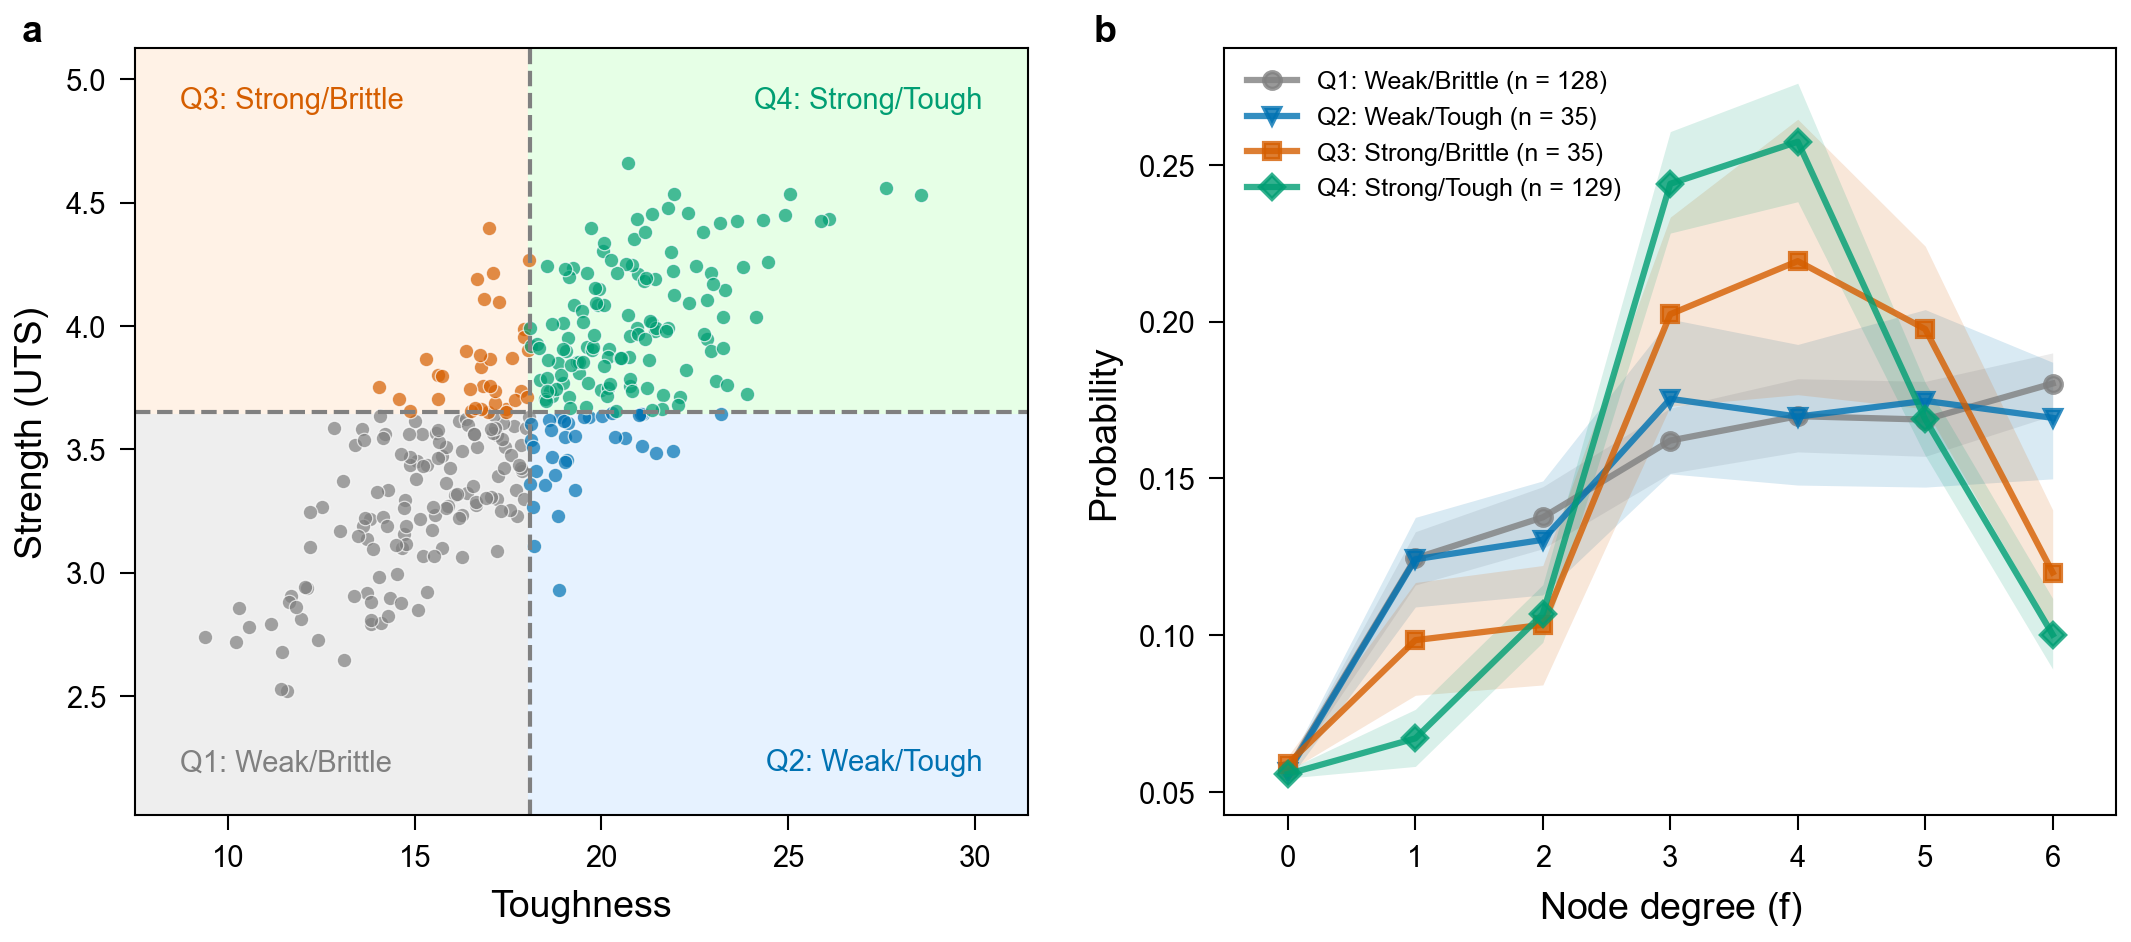

In [6]:
# --- Figure 5: Mechanical State ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import os
import sys

sys.path.append(os.path.abspath('data'))
from npj_style_v1 import set_npj_style

os.makedirs(output_dir, exist_ok=True)

width, _ = set_npj_style(column_type='double')
height = width * 0.45

plt.rcParams['figure.constrained_layout.use'] = True
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width, height), constrained_layout=True)

# ---------------------------------------------------------
# ---------------------------------------------------------
def prep_data():
    # CHANGE (v0.2.0): 12-pull network means (3 axes x 4 velocity seeds); the mock-data fallback is removed
    df = load_mechanics_12pull()
    print(f"Loaded dataset.pkl + derived/mechanics/mechanics_pulls_4seeds.csv with shape {df.shape}")

    for i in range(7):
        if f'cnt_d{i}' not in df.columns:
            raise KeyError(f'cnt_d{i} missing from the network table')

    return df

# --- Execution ---
df = prep_data()

# ---------------------------------------------------------
# ---------------------------------------------------------
uts_med = df['uts_mean'].median()
tough_med = df['toughness_mean'].median()

def assign_quadrant(row):
    high_uts = row['uts_mean'] >= uts_med
    high_tough = row['toughness_mean'] >= tough_med
    if not high_uts and not high_tough: return 'Q1: Weak/Brittle'
    if not high_uts and high_tough: return 'Q2: Weak/Tough'
    if high_uts and not high_tough: return 'Q3: Strong/Brittle'
    if high_uts and high_tough: return 'Q4: Strong/Tough'
    return 'Unknown'

df['Quadrant'] = df.apply(assign_quadrant, axis=1)
quad_sizes = df['Quadrant'].value_counts().reindex(['Q1: Weak/Brittle', 'Q2: Weak/Tough', 'Q3: Strong/Brittle', 'Q4: Strong/Tough'])
print('quadrant sizes (12-pull means):', quad_sizes.to_dict())
assert quad_sizes.tolist() == [128, 35, 35, 129]

# ---------------------------------------------------------
# ---------------------------------------------------------

# --- Panel a: Mechanical Property Map ---
x_min, x_max = df['toughness_mean'].min(), df['toughness_mean'].max()
y_min, y_max = df['uts_mean'].min(), df['uts_mean'].max()
xlim = (x_min * 0.8, x_max * 1.1)
ylim = (y_min * 0.8, y_max * 1.1)

quad_colors = {
    'Q1: Weak/Brittle': '#eeeeee', 'Q2: Weak/Tough': '#e6f2ff',
    'Q3: Strong/Brittle': '#fff2e6', 'Q4: Strong/Tough': '#e6ffe6',
    'Unknown': 'white'
}
points_colors = {
    'Q1: Weak/Brittle': 'gray', 'Q2: Weak/Tough': '#0072B2',
    'Q3: Strong/Brittle': '#D55E00', 'Q4: Strong/Tough': '#009E73',
    'Unknown': 'black'
}

ax1.fill_between([0, tough_med], 0, uts_med, color=quad_colors['Q1: Weak/Brittle'], alpha=1)
ax1.fill_between([tough_med, xlim[1]*1.5], 0, uts_med, color=quad_colors['Q2: Weak/Tough'], alpha=1)
ax1.fill_between([0, tough_med], uts_med, ylim[1]*1.5, color=quad_colors['Q3: Strong/Brittle'], alpha=1)
ax1.fill_between([tough_med, xlim[1]*1.5], uts_med, ylim[1]*1.5, color=quad_colors['Q4: Strong/Tough'], alpha=1)

quad_order = ['Q1: Weak/Brittle', 'Q2: Weak/Tough', 'Q3: Strong/Brittle', 'Q4: Strong/Tough']
for q in quad_order:
    subset = df[df['Quadrant'] == q]
    ax1.scatter(subset['toughness_mean'], subset['uts_mean'], s=12, 
                color=points_colors[q], alpha=0.7, edgecolors='w', linewidth=0.3)

ax1.axhline(uts_med, color='gray', linestyle='--', linewidth=1.0) # Thicker (0.8->1.0)
ax1.axvline(tough_med, color='gray', linestyle='--', linewidth=1.0)

margin_x = (xlim[1] - xlim[0]) * 0.05
margin_y = (ylim[1] - ylim[0]) * 0.05

ax1.text(xlim[0] + margin_x, ylim[0] + margin_y, 'Q1: Weak/Brittle', ha='left', va='bottom', fontsize=7, color='gray')
ax1.text(xlim[1] - margin_x, ylim[0] + margin_y, 'Q2: Weak/Tough', ha='right', va='bottom', fontsize=7, color='#0072B2')
ax1.text(xlim[0] + margin_x, ylim[1] - margin_y, 'Q3: Strong/Brittle', ha='left', va='top', fontsize=7, color='#D55E00')
ax1.text(xlim[1] - margin_x, ylim[1] - margin_y, 'Q4: Strong/Tough', ha='right', va='top', fontsize=7, color='#009E73')

ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel('Toughness')   # CHANGE (v0.2.0): area under the true stress-strain curve, not energy to break
ax1.set_ylabel('Strength (UTS)')

# --- Panel b: Degree Distribution Evolution (Discrete) ---

def reconstruct_degrees(quadrant_name):
    subset = df[df['Quadrant'] == quadrant_name]
    degrees = []
    total_counts = np.zeros(7)
    for i in range(7):
        if f'cnt_d{i}' in subset.columns:
            total_counts[i] = subset[f'cnt_d{i}'].sum()

    total = np.sum(total_counts)
    if total > 0:
        freqs = total_counts / total
    else:
        freqs = np.zeros(7)
    return freqs

x_degrees = np.arange(7)

linestyles = {
    'Q1: Weak/Brittle': ':',
    'Q2: Weak/Tough': '-.',
    'Q3: Strong/Brittle': '--',
    'Q4: Strong/Tough': '-'
}
markers = {
    'Q1: Weak/Brittle': 'o',
    'Q2: Weak/Tough': 'v',
    'Q3: Strong/Brittle': 's',
    'Q4: Strong/Tough': 'D'
}

# CHANGE (v0.2.0): 95% network-bootstrap band of each quadrant-pooled distribution (2000 resamples, seed 0)
# and the number of networks per quadrant in the legend
_rng = np.random.default_rng(0)
FIG5B_BANDS = {}
for q in quad_order:
    freqs = reconstruct_degrees(q)
    sub = df[df['Quadrant'] == q]
    _C = sub[[f'cnt_d{i}' for i in range(7)]].to_numpy(float)
    _B = np.array([(lambda c: c / c.sum())(_C[_rng.integers(0, len(_C), len(_C))].sum(0)) for _ in range(2000)])
    _lo, _hi = np.percentile(_B, 2.5, axis=0), np.percentile(_B, 97.5, axis=0)
    FIG5B_BANDS[q] = (freqs, _lo, _hi, len(sub))
    ax2.fill_between(x_degrees, _lo, _hi, color=points_colors[q], alpha=0.15, linewidth=0, zorder=1)
    ax2.plot(x_degrees, freqs, color=points_colors[q], linestyle=linestyles['Q4: Strong/Tough'], 
             marker=markers[q], markersize=4, linewidth=1.5, label=f'{q} (n = {len(sub)})', alpha=0.8, zorder=3)

ax2.set_xlabel(r'Node degree ($f$)') 
ax2.set_ylabel('Probability')
ax2.set_xlim(-0.5, 6.5)
ax2.set_xticks([0, 1, 2, 3, 4, 5, 6])
ax2.legend(frameon=False, loc='upper left', fontsize=6)

def align_label_to_ylabel(ax, label_text):
    fig.canvas.draw()
    ylabel = ax.yaxis.label
    bbox = ylabel.get_window_extent(renderer=fig.canvas.get_renderer())
    ylabel_center_x = (bbox.x0 + bbox.x1) / 2
    ax_bbox = ax.get_window_extent()
    ax_width = ax_bbox.width
    x_rel = (ylabel_center_x - ax_bbox.x0) / ax_width
    ax.text(x_rel, 1.0, label_text, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='bottom', ha='center')

align_label_to_ylabel(ax1, 'a')
align_label_to_ylabel(ax2, 'b')

# CHANGE (v0.2.0): PDF as in the manuscript; fig.savefig, PNG then PDF, as in the script that made the
# manuscript files (plt.savefig redraws the figure between the saves and moves the layout by a fraction of a point)
fig.savefig(os.path.join(output_dir, 'Figure_5_Mechanical_State.png'), dpi=SAVE_DPI)
fig.savefig(os.path.join(output_dir, 'Figure_5_Mechanical_State.pdf'), dpi=SAVE_DPI)
print("Figure 5 generated successfully.")

# CHANGE (v0.2.0): check the bands against the reference table (data/derived/figure_stats/figure5b_degree_bands_k12.csv)
_band = read_csv_exact(os.path.join(REV_PATH, 'figure_stats', 'figure5b_degree_bands_k12.csv'))
_dband = 0.0
for q, (fr, lo, hi, nq) in FIG5B_BANDS.items():
    ref = _band[_band.quadrant == q].sort_values('degree')
    assert (ref.n == nq).all()
    _dband = max(_dband, np.abs(ref.ci_low.to_numpy() - lo).max(), np.abs(ref.ci_high.to_numpy() - hi).max(), np.abs(ref.p.to_numpy() - fr).max())
print(f"Figure 5b bands vs figure5b_degree_bands_k12.csv: max |difference| = {_dband:.1e}")
assert _dband < 1e-12

Calculating Degree Metrics...


Figure 6 generated successfully.
heatmap vs figure6_stats.csv: max |d diff| = 2.2e-16, max |q diff| = 0.0e+00, asterisk mismatches = 0
asterisks: 31 of 55 cells (BH q < 0.05)
panel b/c bars vs figure6_bars.csv: max |difference| = 2.2e-16 (b: 10 bars, c: 10 bars)


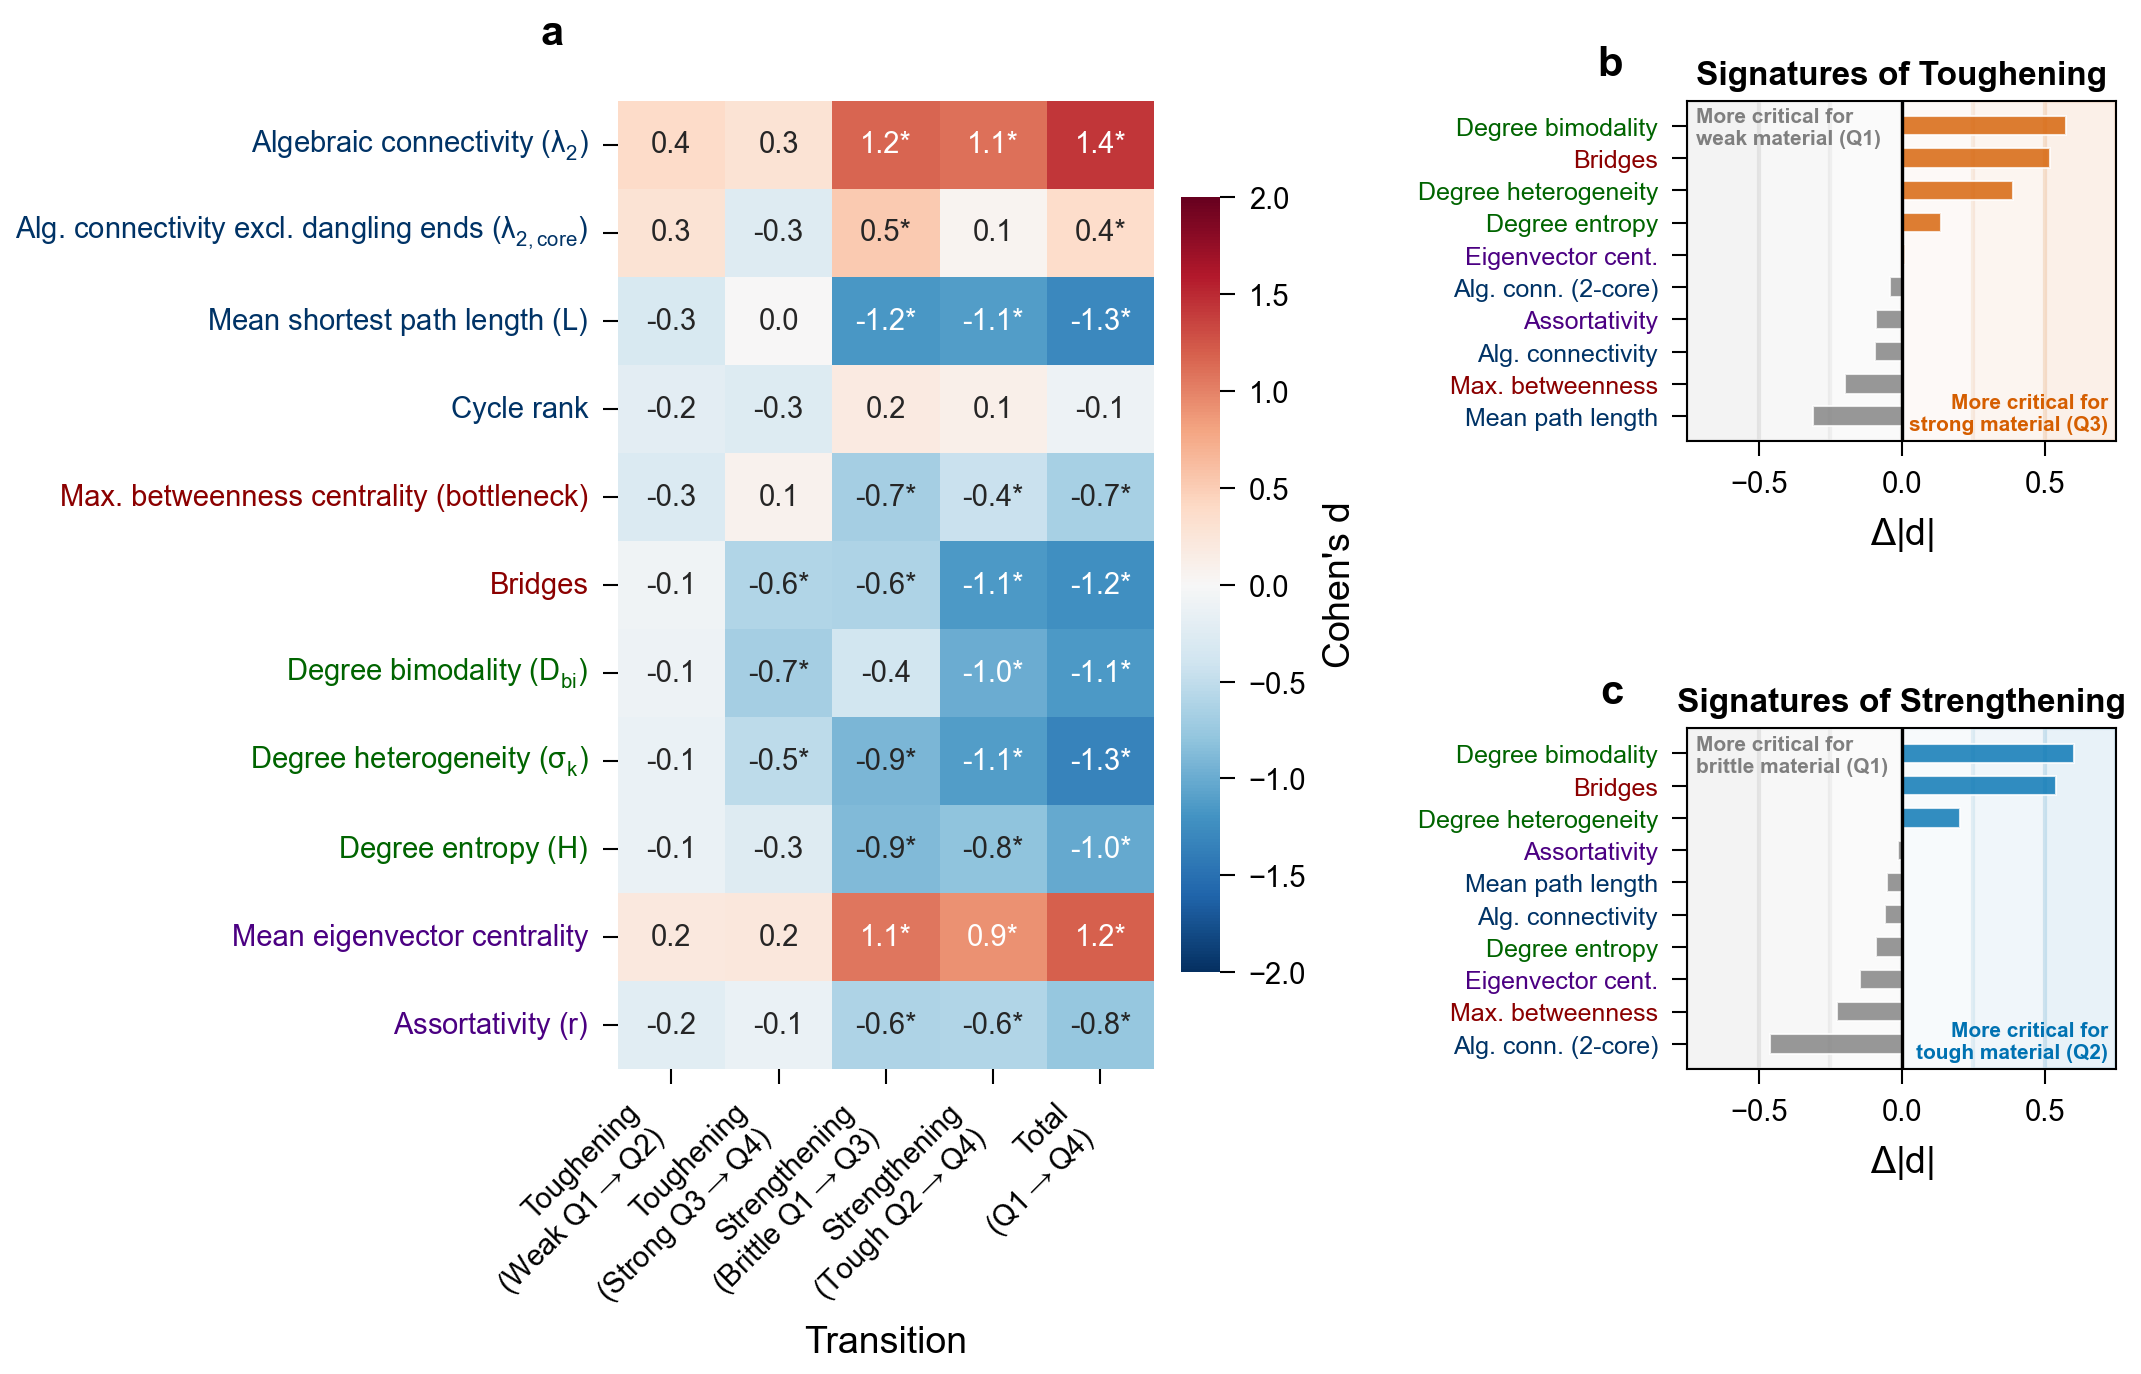

In [7]:
# --- Figure 6: Contrast Maps (Final) ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind
import os
import sys

sys.path.append(os.path.abspath('data'))
from npj_style_v1 import set_npj_style

os.makedirs(output_dir, exist_ok=True)

width, _ = set_npj_style(column_type='double')
height = width * 0.65 

plt.rcParams['figure.constrained_layout.use'] = True
fig = plt.figure(figsize=(width, height), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1.25, 1])

ax_hm = fig.add_subplot(gs[:, 0])      # Left (Heatmap)
ax_top = fig.add_subplot(gs[0, 1])     # Top Right (Toughening)
ax_bot = fig.add_subplot(gs[1, 1])     # Bottom Right (Strengthening)

# ---------------------------------------------------------
# ---------------------------------------------------------
def prep_data():
    # CHANGE (v0.2.0): 12-pull network means (3 axes x 4 velocity seeds); the mock-data fallbacks are removed
    df = load_mechanics_12pull()

    # --- ENRICHMENT LOGIC (Calculate missing columns) ---
    # CHANGE (v0.2.0): cycle rank of the active graph, E - N_active + 1 (the deposited cyclomatic_idx);
    # the published figure counted the degree-0 vacancies as nodes (E - 216 + 1)
    df['cycle_rank'] = df['cyclomatic_idx']

    needed_deg = ['deg_bimodality', 'deg_std', 'deg_entropy', 'deg_heterogeneity']
    if any(m not in df.columns for m in needed_deg) and 'cnt_d0' in df.columns:
        print("Calculating Degree Metrics...")
        from scipy.stats import skew, kurtosis

        def calc_dist_metrics(row):
            degrees = []
            counts_arr = []
            for d in range(7):
                if f'cnt_d{d}' in row:
                    count = int(row[f'cnt_d{d}'])
                    degrees.extend([d] * count)
                    counts_arr.append(count)

            arr = np.array(degrees, dtype=float)
            counts_arr = np.array(counts_arr)

            if len(arr) == 0: return pd.Series([0]*9) # Fallback

            g = skew(arr)
            k = kurtosis(arr) 

            counts_float = counts_arr.astype(float)
            probs = counts_float / np.sum(counts_float) if np.sum(counts_float)>0 else counts_float
            probs_nonzero = probs[probs > 0]
            ent = -np.sum(probs_nonzero * np.log(probs_nonzero))

            k_pearson = k + 3
            bc = (g**2 + 1) / k_pearson if k_pearson != 0 else 0

            k1 = np.mean(arr)
            k2 = np.mean(arr**2)
            kappa = k2 / k1 if k1 > 0 else 0

            std_val = np.std(arr)

            return pd.Series([std_val, ent, bc, kappa], 
                             index=['deg_std', 'deg_entropy', 'deg_bimodality', 'assortativity_dummy']) 

        deg_res = df.apply(calc_dist_metrics, axis=1)
        for m in ['deg_std', 'deg_entropy', 'deg_bimodality']:
            if m not in df.columns:   # CHANGE (v0.2.0): keep the deposited deg_std and deg_entropy, add only what is missing
                df[m] = deg_res[m]

    missing_physics = [k for k in ['lambda_2', 'assortativity'] if k not in df.columns]
    if missing_physics:
         raise KeyError(f"Missing graph-descriptor columns {missing_physics}")   # CHANGE (v0.2.0): no mock data

    return df

df = prep_data()

uts_med = df['uts_mean'].median()
tough_med = df['toughness_mean'].median()
def assign_quadrant(row):
    high_uts = row['uts_mean'] >= uts_med
    high_tough = row['toughness_mean'] >= tough_med
    if not high_uts and not high_tough: return 'Q1: Weak/Brittle'
    if not high_uts and high_tough: return 'Q2: Weak/Tough'
    if high_uts and not high_tough: return 'Q3: Strong/Brittle'
    if high_uts and high_tough: return 'Q4: Strong/Tough'
    return 'Unknown'
df['Quadrant'] = df.apply(assign_quadrant, axis=1)

# ---------------------------------------------------------
# ---------------------------------------------------------

# CHANGE (v0.2.0): neutral (mathematical) metric names
map_long = {
    'lambda_2': r'Algebraic connectivity ($\lambda_2$)',
    'lambda_2_core': r'Alg. connectivity excl. dangling ends ($\lambda_{2,core}$)',
    'avg_path_len': r'Mean shortest path length ($L$)',
    'cycle_rank': r'Cycle rank',
    'max_betweenness': r'Max. betweenness centrality (bottleneck)',
    'num_bridges': r'Bridges',
    'deg_bimodality': r'Degree bimodality ($D_{bi}$)',
    'deg_std': r'Degree heterogeneity ($\sigma_k$)',
    'deg_entropy': r'Degree entropy ($H$)',
    'assortativity': r'Assortativity ($r$)',
    'avg_eigenvector_cent': r'Mean eigenvector centrality'
}

map_clean = {'lambda_2': 'Alg. connectivity', 'lambda_2_core': 'Alg. conn. (2-core)',
             'avg_path_len': 'Mean path length', 'cycle_rank': 'Cycle rank',
             'max_betweenness': 'Max. betweenness', 'num_bridges': 'Bridges',
             'deg_bimodality': 'Degree bimodality', 'deg_std': 'Degree heterogeneity',
             'deg_entropy': 'Degree entropy', 'assortativity': 'Assortativity',
             'avg_eigenvector_cent': 'Eigenvector cent.'}   # short neutral names keep the original b/c width

families = {
    'Global Mechanics': ['lambda_2', 'lambda_2_core', 'avg_path_len', 'cycle_rank'],
    'Critical Defects': ['max_betweenness', 'num_bridges'],
    'Degree Statistics': ['deg_bimodality', 'deg_std', 'deg_entropy'],
    'Network Order': ['avg_eigenvector_cent', 'assortativity']
}
family_colors = {
    'Global Mechanics': '#003366',      # Navy Blue
    'Critical Defects': '#8B0000',      # Dark Red
    'Degree Statistics': '#006400',     # Forest Green
    'Network Order': '#4B0082'          # Indigo/Purple
}

long_to_color = {}
clean_to_color = {}
for family, members in families.items():
    c = family_colors[family]
    for m in members:
        if m in map_long: long_to_color[map_long[m]] = c
        if m in map_clean: clean_to_color[map_clean[m]] = c

ordered_features = []
for fam in families.values():
    ordered_features.extend(fam)
features = [k for k in ordered_features if k in df.columns]

def cohens_d(x, y):
    nx = len(x); ny = len(y); dof = nx + ny - 2
    pool_std = np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pool_std if pool_std != 0 else 0

def analyze_transition_stats(start_q, end_q):
    g_start = df[df['Quadrant'] == start_q]
    g_end = df[df['Quadrant'] == end_q]
    d_vals = {}; sig_vals = {}
    for feat in features:
        val_start = g_start[feat].dropna(); val_end = g_end[feat].dropna()
        d_vals[feat] = cohens_d(val_end, val_start)
        if len(val_start) > 1 and len(val_end) > 1:
            stat, pval = ttest_ind(val_start, val_end, equal_var=False)
            sig_vals[feat] = pval < 0.05
        else: sig_vals[feat] = False
    return pd.Series(d_vals), pd.Series(sig_vals)

d_tough_wk, sig_tough_wk = analyze_transition_stats('Q1: Weak/Brittle', 'Q2: Weak/Tough')
d_tough_str, sig_tough_str = analyze_transition_stats('Q3: Strong/Brittle', 'Q4: Strong/Tough')
d_str_brit, sig_str_brit = analyze_transition_stats('Q1: Weak/Brittle', 'Q3: Strong/Brittle')
d_str_tough, sig_str_tough = analyze_transition_stats('Q2: Weak/Tough', 'Q4: Strong/Tough')
d_total, sig_total = analyze_transition_stats('Q1: Weak/Brittle', 'Q4: Strong/Tough')

# CHANGE (v0.2.0): the panel-b/c bars show the same 10 descriptors (all but cycle rank) in both panels;
# the published figure showed those with raw p < 0.05 in either transition
BAR_FEATURES = ['lambda_2', 'lambda_2_core', 'avg_path_len', 'max_betweenness', 'num_bridges',
                'deg_bimodality', 'deg_std', 'deg_entropy', 'avg_eigenvector_cent', 'assortativity']

def filter_and_diff_magnitude(d1, sig1, d2, sig2):
    diffs = {}
    for feat in features:
        if feat in BAR_FEATURES:
            mag_diff = abs(d2.get(feat, 0)) - abs(d1.get(feat, 0))
            diffs[feat] = mag_diff
    return pd.Series(diffs)

diff_toughening = filter_and_diff_magnitude(d_tough_wk, sig_tough_wk, d_tough_str, sig_tough_str)
diff_strengthening = filter_and_diff_magnitude(d_str_brit, sig_str_brit, d_str_tough, sig_str_tough)

# ---------------------------------------------------------
# ---------------------------------------------------------

# --- Panel A: Heatmap ---
transitions = {
    'Toughening\n(Weak Q1$\\rightarrow$Q2)': (d_tough_wk, sig_tough_wk),
    'Toughening\n(Strong Q3$\\rightarrow$Q4)': (d_tough_str, sig_tough_str),
    'Strengthening\n(Brittle Q1$\\rightarrow$Q3)': (d_str_brit, sig_str_brit),
    'Strengthening\n(Tough Q2$\\rightarrow$Q4)': (d_str_tough, sig_str_tough),
    'Total\n(Q1$\\rightarrow$Q4)': (d_total, sig_total)
}

hm_data = []
for t_name, (d_ser, sig_ser) in transitions.items():
    for feat in features:
        hm_data.append({
            'Feature': feat, 'Transition': t_name,
            'd': d_ser.get(feat, np.nan), 'sig': sig_ser.get(feat, False)
        })

df_hm = pd.DataFrame(hm_data)
pivot_d = df_hm.pivot(index='Feature', columns='Transition', values='d')
pivot_sig = df_hm.pivot(index='Feature', columns='Transition', values='sig')

pivot_d = pivot_d.reindex(features)
pivot_sig = pivot_sig.reindex(features)

pivot_d = pivot_d.rename(index=map_long)
pivot_sig = pivot_sig.rename(index=map_long)

col_order = [
    'Toughening\n(Weak Q1$\\rightarrow$Q2)', 'Toughening\n(Strong Q3$\\rightarrow$Q4)',
    'Strengthening\n(Brittle Q1$\\rightarrow$Q3)', 'Strengthening\n(Tough Q2$\\rightarrow$Q4)',
    'Total\n(Q1$\\rightarrow$Q4)'
]
pivot_d = pivot_d[col_order]

# CHANGE (v0.2.0): asterisks = Benjamini-Hochberg q < 0.05 over the 55 Welch tests (was raw p < 0.05)
pairs = [('Q1: Weak/Brittle', 'Q2: Weak/Tough'), ('Q3: Strong/Brittle', 'Q4: Strong/Tough'),
         ('Q1: Weak/Brittle', 'Q3: Strong/Brittle'), ('Q2: Weak/Tough', 'Q4: Strong/Tough'),
         ('Q1: Weak/Brittle', 'Q4: Strong/Tough')]
pivot_p = pd.DataFrame(np.nan, index=pivot_d.index, columns=col_order)
for col, (qa, qb) in zip(col_order, pairs):
    for feat in features:
        pivot_p.loc[map_long[feat], col] = ttest_ind(df.loc[df['Quadrant'] == qa, feat].dropna(),
                                                     df.loc[df['Quadrant'] == qb, feat].dropna(), equal_var=False)[1]
_pv = pivot_p.to_numpy().ravel(); _m = len(_pv); _o = np.argsort(_pv)
_q = np.empty(_m); _q[_o] = np.minimum(1.0, np.minimum.accumulate((_pv[_o] * _m / np.arange(1, _m + 1))[::-1])[::-1])
pivot_q = pd.DataFrame(_q.reshape(pivot_p.shape), index=pivot_p.index, columns=pivot_p.columns)
pivot_sig = pivot_q < 0.05

annot_labels = pivot_d.round(1).astype(str)
for col in pivot_d.columns:
    for idx in pivot_d.index:
        if pivot_sig.loc[idx, col]: annot_labels.loc[idx, col] += '*'

sns.heatmap(pivot_d, annot=annot_labels, fmt='', cmap='RdBu_r', center=0, 
            vmin=-2.0, vmax=2.0, ax=ax_hm, cbar_kws={'label': "Cohen's $d$", 'shrink': 0.8},
            annot_kws={'fontsize': 7}) # Removed 'color'='white' to allow auto-contrast

ax_hm.set_xticklabels(col_order, rotation=45, ha='right', fontsize=7)
ax_hm.text(-0.1, 1.05, 'a', transform=ax_hm.transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')
ax_hm.set_ylabel('')

for tick in ax_hm.get_yticklabels():
    txt = tick.get_text()
    if txt in long_to_color:
        tick.set_color(long_to_color[txt])

# --- Panel B & C: Contrast Bars ---
def plot_contrast_grad(ax, series, title, left_text, right_text, left_color, right_color, panel_label):
    if series.empty: return
    series = series.rename(index=map_clean)
    series = series.sort_values(ascending=True)

    ax.axvspan(-0.25, 0, color=left_color, alpha=0.03)
    ax.axvspan(0, 0.25, color=right_color, alpha=0.03)
    ax.axvspan(-0.5, -0.25, color=left_color, alpha=0.06)
    ax.axvspan(0.25, 0.5, color=right_color, alpha=0.06)
    ax.axvspan(-0.75, -0.5, color=left_color, alpha=0.09)
    ax.axvspan(0.5, 0.75, color=right_color, alpha=0.09)

    colors = [left_color if v < 0 else right_color for v in series.values]
    y_pos = np.arange(len(series))
    ax.barh(y_pos, series.values, color=colors, alpha=0.8, height=0.6, edgecolor='white', linewidth=0.5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(series.index, fontsize=6)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=8, fontweight='bold', pad=4)
    ax.set_xlim(-0.75, 0.75)
    ax.set_xlabel(r'$\Delta |d|$')

    for tick in ax.get_yticklabels():
        txt = tick.get_text()
        if txt in clean_to_color:
            tick.set_color(clean_to_color[txt])

    ax.text(0.02, 0.98, left_text, transform=ax.transAxes, fontsize=5, color=left_color, fontweight='bold', ha='left', va='top')
    ax.text(0.98, 0.02, right_text, transform=ax.transAxes, fontsize=5, color=right_color, fontweight='bold', ha='right', va='bottom')

    ax.text(-0.15, 1.05, panel_label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')

plot_contrast_grad(ax_top, diff_toughening,
                  'Signatures of Toughening',
                  'More critical for\nweak material (Q1)',      # CHANGE (v0.2.0): three-line corner notes
                  'More critical for\nstrong material (Q3)',
                  '#7f7f7f', '#D55E00', 'b')

plot_contrast_grad(ax_bot, diff_strengthening,
                  'Signatures of Strengthening',
                  'More critical for\nbrittle material (Q1)',
                  'More critical for\ntough material (Q2)',
                  '#7f7f7f', '#0072B2', 'c')

# CHANGE (v0.2.0): PDF as in the manuscript; fig.savefig, PNG then PDF, as in the script that made the
# manuscript files (plt.savefig redraws the figure between the saves and moves the layout by a fraction of a point)
fig.savefig(os.path.join(output_dir, 'Figure_6_Contrast_Maps.png'), dpi=SAVE_DPI)
fig.savefig(os.path.join(output_dir, 'Figure_6_Contrast_Maps.pdf'), dpi=SAVE_DPI)
print("Figure 6 generated successfully.")

# CHANGE (v0.2.0): check the heatmap and bars against the reference tables (data/derived/figure_stats/)
_ref = read_csv_exact(os.path.join(REV_PATH, 'figure_stats', 'figure6_stats.csv'))
_nm = {'Algebraic connectivity (lambda_2)': 'lambda_2', 'Algebraic connectivity excl. dangling ends (lambda_2,core)': 'lambda_2_core',
       'Mean shortest path length (L)': 'avg_path_len', 'Cycle rank': 'cycle_rank', 'Max. betweenness centrality': 'max_betweenness',
       'Bridges': 'num_bridges', 'Degree bimodality (D_bi)': 'deg_bimodality', 'Degree heterogeneity (sigma_k)': 'deg_std',
       'Degree entropy (H)': 'deg_entropy', 'Mean eigenvector centrality': 'avg_eigenvector_cent', 'Assortativity (r)': 'assortativity'}
_tr = {'Toughening (weak, Q1->Q2)': 0, 'Toughening (strong, Q3->Q4)': 1, 'Strengthening (brittle, Q1->Q3)': 2,
       'Strengthening (tough, Q2->Q4)': 3, 'Total (Q1->Q4)': 4}
_dmax = _qmax = 0.0; _star_mismatch = 0
for _, r in _ref.iterrows():
    _row = map_long[_nm[r.metric]]; _col = col_order[_tr[r.transition]]
    _dmax = max(_dmax, abs(pivot_d.loc[_row, _col] - r.cohens_d)); _qmax = max(_qmax, abs(pivot_q.loc[_row, _col] - r.bh_q))
    _star_mismatch += int(bool(pivot_sig.loc[_row, _col]) != bool(r.sig_bh))
print(f"heatmap vs figure6_stats.csv: max |d diff| = {_dmax:.1e}, max |q diff| = {_qmax:.1e}, asterisk mismatches = {_star_mismatch}")
print(f"asterisks: {int(pivot_sig.to_numpy().sum())} of {pivot_sig.size} cells (BH q < 0.05)")
assert _dmax < 1e-12 and _qmax < 1e-12 and _star_mismatch == 0 and int(pivot_sig.to_numpy().sum()) == 31
_bars = read_csv_exact(os.path.join(REV_PATH, 'figure_stats', 'figure6_bars.csv'))
_bmax = 0.0
for lab, ser in (('panel b', diff_toughening), ('panel c', diff_strengthening)):
    for feat, v in ser.items():
        ref = _bars[(_bars.metric.map(_nm) == feat) & _bars.bar.str.startswith(lab)].delta_abs_d.iloc[0]
        _bmax = max(_bmax, abs(v - ref))
print(f"panel b/c bars vs figure6_bars.csv: max |difference| = {_bmax:.1e} (b: {len(diff_toughening)} bars, c: {len(diff_strengthening)} bars)")
assert _bmax < 1e-12 and len(diff_toughening) == len(diff_strengthening) == 10

In [8]:
# --- Pearson Correlation Matrix ---

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.stats import skew, kurtosis

# CHANGE (v0.2.0): 12-pull network means (the table of the Figure 6 cell); no silent fallback
if 'df' not in locals() or df is None or df['num_directions'].iloc[0] != 12:
    df = load_mechanics_12pull()

if df is not None:
    if 'deg_bimodality' not in df.columns:
        deg_cols = [c for c in df.columns if c.startswith('cnt_d') and c[5:].isdigit()]
        if deg_cols:
            def calc_bimodality(row):
                degrees = []
                for c in deg_cols:
                    k = int(c.split('_d')[1])
                    count = int(row[c])
                    degrees.extend([k] * count)
                if len(degrees) < 2: return np.nan
                k_p = kurtosis(degrees, fisher=True) + 3
                s = skew(degrees)
                return (s**2 + 1) / k_p
            df['deg_bimodality'] = df.apply(calc_bimodality, axis=1)

    df['cycle_rank'] = df['cyclomatic_idx']   # CHANGE (v0.2.0): cycle rank of the active graph, as in Figure 6

feature_map = {   # CHANGE (v0.2.0): neutral names, as in Figure 6
    'lambda_2': 'Algebraic connectivity', 'lambda_2_core': 'Alg. conn. excl. dangling ends',
    'avg_path_len': 'Mean shortest path', 'cycle_rank': 'Cycle rank',
    'max_betweenness': 'Max. betweenness', 'num_bridges': 'Bridges',
    'deg_bimodality': 'Degree bimodality', 'deg_std': 'Degree heterogeneity',
    'deg_entropy': 'Degree entropy', 'assortativity': 'Assortativity',
    'avg_eigenvector_cent': 'Mean eigenvector centrality'
}
target_map = {'toughness_mean': 'Toughness', 'uts_mean': 'Strength'}
family_colors = {
    'Global Mechanics': '#003366', 'Critical Defects': '#8B0000',
    'Degree Statistics': '#006400', 'Network Order': '#4B0082'
}
families = {
    'Global Mechanics': ['lambda_2', 'lambda_2_core', 'avg_path_len', 'cycle_rank'],
    'Critical Defects': ['max_betweenness', 'num_bridges'],
    'Degree Statistics': ['deg_bimodality', 'deg_std', 'deg_entropy'],
    'Network Order': ['avg_eigenvector_cent', 'assortativity']
}
label_to_color = {}
for fam, members in families.items():
    for m in members:
        if m in feature_map: label_to_color[feature_map[m]] = family_colors[fam]

if df is not None:
    plt.close('all') 
    selected_features = [f for f in feature_map.keys() if f in df.columns]
    selected_targets = [t for t in target_map.keys() if t in df.columns]
    cols_to_plot = selected_features + selected_targets
    labels = [feature_map[f] for f in selected_features] + [target_map[t] for t in selected_targets]

    if cols_to_plot:
        corr_matrix = df[cols_to_plot].corr(method='pearson')
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111)
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, annot=True, mask=mask, cmap='coolwarm', fmt=".2f", 
                    linewidths=0.5, center=0, vmin=-1, vmax=1,
                    xticklabels=labels, yticklabels=labels, ax=ax, cbar_kws={'shrink': 0.8})
        ax.set_title('Features vs Mechanical Performance  (12-pull means: 3 axes x 4 seeds)', fontsize=15, pad=20)   # CHANGE (v0.2.0)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
        plt.setp(ax.get_yticklabels(), fontsize=12)
        for tick in ax.get_yticklabels() + ax.get_xticklabels():
            if tick.get_text() in label_to_color: tick.set_color(label_to_color[tick.get_text()])

        plt.subplots_adjust(bottom=0.25, left=0.25, top=0.9, right=0.95)
        save_path = os.path.join(output_dir, 'pearson_correlation_matrix.png')
        plt.savefig(save_path, dpi=SAVE_DPI)
        plt.close()
        print(f"Successfully saved Pearson plot to {save_path}")

Successfully saved Pearson plot to figs\pearson_correlation_matrix.png


In [9]:
# --- Figures 8 (Appendix B, entanglement) and 9 (Appendix C, bond/create, with alternative versions) ---
# Appendix figures (Fig. 8, entanglement range, Appendix B. Fig. 9, bond/create comparison, Appendix C) in the npj_style_v1 style
# of the other manuscript figures. Run from demos/npjcompmat/ (same code as the notebook cells).
import csv
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath('data'))
from npj_style_v1 import set_npj_style

output_dir = 'figs'
os.makedirs(output_dir, exist_ok=True)
SAVE_DPI = 600
REV_PATH = os.path.join('data', 'derived')


def require(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required input not found: {path}. Run from demos/npjcompmat/.")
    return path


def align_label_to_ylabel(fig, ax, label_text):
    # panel letter centred over the y-axis label, as in Figure 1
    ylabel = ax.yaxis.label
    bbox = ylabel.get_window_extent(renderer=fig.canvas.get_renderer())
    ax_bbox = ax.get_window_extent()
    x_rel = ((bbox.x0 + bbox.x1) / 2 - ax_bbox.x0) / ax_bbox.width
    ax.text(x_rel, 1.0, label_text, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='bottom', ha='center')


REF_C, TOP_C = '#7f7f7f', '#0072B2'

# =====================================================================================================
# Figure 9 (Appendix C): bond/create references versus Topon networks built from their statistics
# =====================================================================================================
BC = os.path.join(REV_PATH, 'bond_create')
with open(require(os.path.join(BC, 'four_distributions.json')), encoding='utf-8') as fh:
    four = json.load(fh)


def cycle_frac(d, kmax):
    ks = np.arange(3, kmax + 1)
    return ks, np.array([d.get(str(k), 0) for k in ks], float) / sum(d.values())


def load_ss(path, w=100):
    d = np.loadtxt(require(path), skiprows=1, ndmin=2)
    e, s = d[:, 1], d[:, 2]
    ss = np.convolve(s, np.ones(w) / w, 'valid')      # 100 rows = 0.1 strain
    return e[w // 2: w // 2 + len(ss)], ss


width, _ = set_npj_style(column_type='double')
CASES = (('N20', r'$DP=20$'), ('N100', r'$DP=100$'))


def binned_fraction(values, edges):
    h, _ = np.histogram(np.asarray(values, float), bins=edges)
    return 0.5 * (edges[1:] + edges[:-1]), h / len(values)


def draw_bondcreate(first, fname):
    # first column: 'ring' (smallest ring size), 'distance' (junction separation), 'rank' (neighbor rank)
    fig, axes = plt.subplots(2, 3, figsize=(width, width * 0.55), constrained_layout=True)
    for r, (case, tag) in enumerate(CASES):
        ref, top = four[case]['reference'], four[case]['topon']

        ax = axes[r, 0]
        if first == 'ring':
            kmax = 12 if case == 'N20' else 10
            x, fr = cycle_frac(ref['cycle'], kmax)
            _, ft = cycle_frac(top['cycle'], kmax)
            ax.set_xticks(x[::2] if case == 'N20' else x)
            ax.set_xlabel('Smallest ring size (strands)')
        elif first == 'reach':
            # reach = distance between the two junctions of a load-bearing strand / mean junction spacing
            rd = reach_data[case]
            edges = np.arange(0, 3.31, 0.15) if case == 'N20' else np.arange(0, 4.51, 0.25)
            x, fr = binned_fraction(rd['reference']['reach'], edges)
            _, ft = binned_fraction(rd['topon_relaxed']['reach'], edges)
            _, fb = binned_fraction(rd['topon_built']['reach'], edges)
            cut = max(rd['topon_built']['reach'])        # largest lattice distance the cutoff admits
            ax.plot(x, fb, '-', color='#56B4E9', lw=1.0, label='Topon, as built')
            ax.axvline(cut, color='gray', ls='--', lw=0.5)
            ax.set_xlabel(r'Strand reach ($r/a$)')
        elif first == 'distance':
            edges = np.arange(0, 16.01, 1.0) if case == 'N20' else np.arange(0, 40.01, 2.5)
            x, fr = binned_fraction(ref['span'], edges)
            _, ft = binned_fraction(top['span'], edges)
            ax.set_xlabel(r'Distance between connected junctions ($\sigma$)')
        else:
            # ranks were counted up to the 80th neighbor; strands beyond it (8-11% at DP 100) are left out
            edges = np.arange(0.5, 60.6, 4) if case == 'N20' else np.arange(0.5, 80.6, 8)
            x, fr = binned_fraction(ref['rank'], edges)
            _, ft = binned_fraction(top['rank'], edges)
            ax.set_xlabel('Neighbor rank of connected junction')
        ax.plot(x, fr, 's-', color=REF_C, lw=1.5, markersize=4, label='bond/create')
        ax.plot(x, ft, 'o-', color=TOP_C, lw=1.5, markersize=4, label='Topon')
        ax.set_ylim(0, 1.25 * max(fr.max(), ft.max(), fb.max() if first == 'reach' else 0))
        ax.set_ylabel('Fraction of strands')
        ax.text(0.05, 0.88, tag, transform=ax.transAxes, fontsize=8)
        if first == 'reach' and r == 0:
            ax.legend(frameon=False, loc='upper right')

        ax = axes[r, 1]
        zr = np.asarray(ref['Z_bridge_hist'], float); zt = np.asarray(top['Z_bridge_hist'], float)
        n = max(len(zr), len(zt))
        zr = np.pad(zr / zr.sum(), (0, n - len(zr))); zt = np.pad(zt / zt.sum(), (0, n - len(zt)))
        xz = np.arange(n)
        ax.plot(xz, zr, 's-', color=REF_C, lw=1.5, markersize=4)
        ax.plot(xz, zt, 'o-', color=TOP_C, lw=1.5, markersize=4)
        ax.set_xticks(xz)
        ax.set_ylim(0, 1.1 * max(zr.max(), zt.max()))
        ax.set_xlabel(r'Entanglements per strand ($Z$)')
        ax.set_ylabel('Fraction of strands')

        ax = axes[r, 2]
        er, sr = load_ss(os.path.join(BC, f'{case}_reference_stress_strain_high.txt'))
        et, st = load_ss(os.path.join(BC, f'{case}_topon_stress_strain_high.txt'))
        ax.plot(er, sr, '-', color=REF_C, lw=1.0, label='bond/create')
        ax.plot(et, st, '-', color=TOP_C, lw=1.0, label='Topon')
        ax.set_xlim(0, 10 if case == 'N20' else 25)
        ax.set_ylim(bottom=-0.02)
        ax.set_xlabel('Engineering strain')
        ax.set_ylabel(r'Stress ($\epsilon/\sigma^3$)')

    axes[0, 2].legend(frameon=False, loc='upper right')
    fig.canvas.draw()
    for ax, lab in zip(axes.flat, 'abcdef'):
        align_label_to_ylabel(fig, ax, lab)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(output_dir, f'{fname}.{ext}'), dpi=SAVE_DPI)
    plt.close(fig)
    print(f'{fname} written')


with open(require(os.path.join(BC, 'reach_distributions.json')), encoding='utf-8') as fh:
    reach_data = json.load(fh)
draw_bondcreate('reach', 'Figure_A1_bondcreate')                 # Fig. 9 in the manuscript (strand reach r/a)
draw_bondcreate('ring', 'Figure_A1_bondcreate_ring')             # alternative first column (smallest ring)
draw_bondcreate('distance', 'Figure_A1_bondcreate_distance')     # alternative first column
draw_bondcreate('rank', 'Figure_A1_bondcreate_rank')             # alternative first column

# =====================================================================================================
# Figure 8 (Appendix B): requested versus realized entanglement, and the realizable range per strand length
# =====================================================================================================
with open(require(os.path.join(REV_PATH, 'entanglement', 'target_vs_realized.json')), encoding='utf-8') as fh:
    tvr = [r for r in json.load(fh) if 'error' not in r]
with open(require(os.path.join(REV_PATH, 'entanglement', 'figure_completion.json')), encoding='utf-8') as fh:
    fill = [r for r in json.load(fh) if 'error' not in r]

DPS = (20, 40, 80, 120)
DP_COLORS = {20: '#E69F00', 40: '#CC79A7', 80: '#0072B2', 120: '#009E73'}


def mean_sd(v):
    v = np.asarray(v, float)
    return v.mean(), (v.std(ddof=1) if len(v) > 1 else 0.0)


cells = {}
for dp in DPS:
    rows = [(0.0, *mean_sd([r['Zmean'] for r in fill if r['dp'] == dp and r['kind'] == 'zero']), False)]
    for tg in (1.0, 2.0, 4.0, 8.0):
        sel = [r for r in tvr if r['dp'] == dp and r['target'] == tg]
        if sel:
            rows.append((tg, *mean_sd([r['Zmean'] for r in sel]), any(r.get('saturated') for r in sel)))
    if dp == 120:
        zc = [r['Zmean'] for r in fill if r['dp'] == 120 and r['kind'] == 'ceiling']
        rows.append((12.0, *mean_sd(zc), True))
    cells[dp] = rows
floor = {dp: cells[dp][0] for dp in DPS}
ceil = {dp: max((c for c in cells[dp] if c[3]), key=lambda c: c[1]) for dp in DPS}

fig, (axA, axB) = plt.subplots(1, 2, figsize=(width, width * 0.4), constrained_layout=True)

axA.plot([0, 12.5], [0, 12.5], '--', color='gray', lw=0.5, alpha=0.6)
for k, dp in enumerate(DPS):
    t = np.array([c[0] for c in cells[dp]]) + (k - 1.5) * 0.12
    m = np.array([c[1] for c in cells[dp]]); s = np.array([c[2] for c in cells[dp]])
    clamped = np.array([c[3] for c in cells[dp]])
    col = DP_COLORS[dp]
    axA.errorbar(t, m, yerr=s, fmt='-', color=col, lw=1.5, capsize=2, elinewidth=0.8, label=fr'$DP={dp}$')
    axA.plot(t[~clamped], m[~clamped], 'o', color=col, markersize=4)
    axA.plot(t[clamped], m[clamped], 'o', mfc='white', mec=col, markersize=4)
axA.set_xlim(-0.5, 12.5); axA.set_ylim(-0.5, 12.5)
axA.set_xlabel('Requested entanglements per strand')
axA.set_ylabel(r'Realized entanglements per strand ($Z$)')
axA.legend(frameon=False, loc='upper left')

xs = np.array(DPS, float)
fl = np.array([floor[d][1] for d in DPS]); ce = np.array([ceil[d][1] for d in DPS])
axB.fill_between(xs, fl, ce, color='#0072B2', alpha=0.12, linewidth=0)
axB.plot(xs, ce, 'o-', color='#0072B2', lw=1.5, markersize=4, label='Densest build')
axB.plot(xs, fl, 's-', color=REF_C, lw=1.5, markersize=4, label='Straight strands')
bc_z = [four['N20']['reference']['summary']['Zmean_bridge'], four['N100']['reference']['summary']['Zmean_bridge']]
axB.plot([20, 100], bc_z, 'D', mfc='white', mec='black', markersize=4.5, linestyle='none', label='bond/create')
# CG ensemble of this work: mean of three networks traced with the same junction-to-junction export
axB.plot([30], [np.mean([0.326, 0.352, 0.394])], '^', color='#D55E00', markersize=5, linestyle='none',
         label='CG ensemble (this work)')
axB.set_xlim(0, 130); axB.set_ylim(-0.5, 12.5)
axB.set_xticks([0, 20, 40, 60, 80, 100, 120])
axB.set_xlabel(r'Degree of polymerization ($DP$)')
axB.set_ylabel(r'Entanglements per strand ($Z$)')
axB.legend(frameon=False, loc='upper left')

fig.canvas.draw()
align_label_to_ylabel(fig, axA, 'a')
align_label_to_ylabel(fig, axB, 'b')
for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(output_dir, f'Figure_A2_entanglement.{ext}'), dpi=SAVE_DPI)
plt.close(fig)

with open(os.path.join(output_dir, 'Figure_A2_entanglement_data.csv'), 'w', newline='') as fh:
    w = csv.writer(fh)
    w.writerow(['DP', 'Z_requested', 'Z_realized_mean', 'Z_realized_sd', 'clamped'])
    for dp in DPS:
        for t, m, s, c in cells[dp]:
            w.writerow([dp, t, round(m, 4), round(s, 4), int(c)])
print('Figure 8 (Figure_A2_entanglement) written')
for dp in DPS:
    print(f'DP {dp}: straight strands {floor[dp][1]:.3f}, densest build {ceil[dp][1]:.2f}')


Figure_A1_bondcreate written


Figure_A1_bondcreate_ring written


Figure_A1_bondcreate_distance written


Figure_A1_bondcreate_rank written


Figure 8 (Figure_A2_entanglement) written
DP 20: straight strands 0.016, densest build 2.10
DP 40: straight strands 0.054, densest build 4.00
DP 80: straight strands 0.041, densest build 7.53
DP 120: straight strands 0.025, densest build 10.92
